In [ ]:
pip install torchdiffeq==0.2.4

In [ ]:
pip install cvxpylayers==0.1.6

In [ ]:
pip install diffcp==1.0.23

In [ ]:
pip install gurobipy==11.0.3

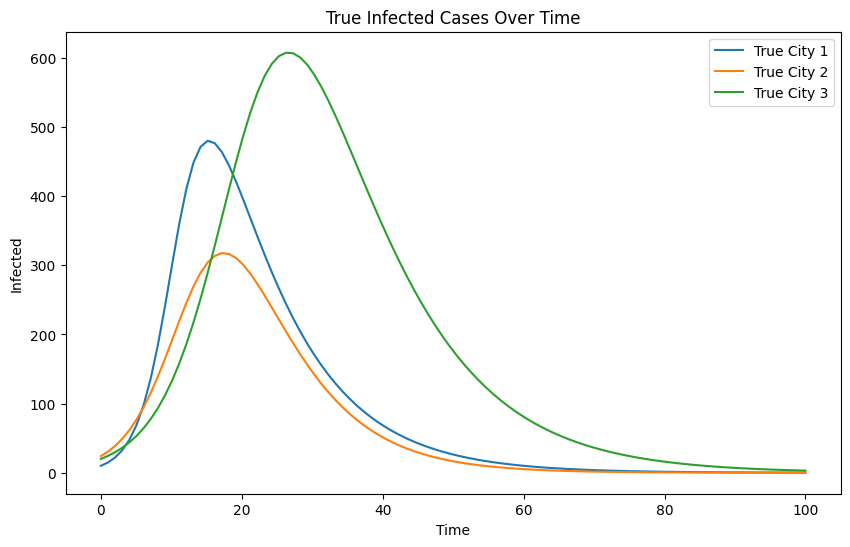

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import gurobipy as gp
from gurobipy import GRB

seed = 0
# Set random seed for reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

# Parameters
num_cities = 3
time_points = torch.linspace(0, 100, 100)

# Total households (population) for each city
total_households = torch.tensor([1000, 1200,2000], dtype=torch.float32)

# Initial conditions
initial_infected = total_households * torch.tensor([0.01, 0.02, 0.01], dtype=torch.float32)  # Different initial infections
initial_recovered = torch.zeros(num_cities)
initial_susceptible = total_households - initial_infected - initial_recovered

initial_conditions = torch.stack([initial_susceptible, initial_infected, initial_recovered], dim=1)

# Beta and gamma parameters for each city
# gamma_true = 0.1  # Recovery rate, same for both cities
gamma_cities = torch.tensor([0.1, 0.15, 0.1], dtype=torch.float32)  # Different gamma for each city
beta_cities = torch.tensor([0.5, 0.4,  0.3], dtype=torch.float32)  # Different beta for each city

# Define the plotting function
# def plot_predictions(time_points, synthetic_outages, pred_outages, customer_tensor, city_indices, title):
#     """
#     Plots the true and predicted outages for each city, including SAIDI and MSE annotations.

#     Args:
#         time_points (torch.tensor): Time points used in simulation.
#         synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
#         pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
#         customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
#         city_indices (list): List of city indices to plot.
#         title (str): Title of the plot.
#     """
#     for city in city_indices:
#         # Extract true and predicted infected cases for the city
#         true_infected = synthetic_outages[:, city, 1].numpy()
#         pred_infected = pred_outages[:, city, 1].detach().numpy()

#         # Calculate SAIDI for the city
#         outage_true = synthetic_outages[:, city, 1].numpy()
#         outage_pred = pred_outages[:, city, 1].detach().numpy()
#         customer = customer_tensor[city].item()

#         saidi_true = np.sum(outage_true) / customer
#         saidi_pred = np.sum(outage_pred) / customer

#         # Calculate MSE for the city
#         mse_value = np.mean((outage_pred - outage_true) ** 2)

#         # Create the plot
#         plt.figure(figsize=(10, 6))
#         plt.plot(time_points.numpy(), outage_true, label=f"True City {city+1}")
#         plt.plot(time_points.numpy(), outage_pred, linestyle='--', label=f"Predicted City {city+1}")
#         plt.xlabel("Time")
#         plt.ylabel("Infected")
#         plt.legend()
#         plt.title(f"{title} - City {city+1}")

#         # Add SAIDI and MSE annotations
#         # Lower left - SAIDI
#         plt.text(0.05, 0.05, f"SAIDI: {saidi_pred:.4f}", transform=plt.gca().transAxes,
#                  fontsize=10, va='bottom', ha='left',
#                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
#         # Lower right - MSE
#         plt.text(0.95, 0.05, f"MSE: {mse_value:.4f}", transform=plt.gca().transAxes,
#                  fontsize=10, va='bottom', ha='right',
#                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

#         plt.show()

# Step 1: Simulate SIR outage data for two cities, not based on wind but allowing their beta differ
class TrueSIRModel(torch.nn.Module):
    def __init__(self, beta_cities, gamma_cities):
        super(TrueSIRModel, self).__init__()
        self.beta_cities = beta_cities  # tensor of shape (num_cities,)
        self.gamma_cities = gamma_cities

    def forward(self, t, y):
        S = y[:, 0]
        I = y[:, 1]
        R = y[:, 2]
        beta = self.beta_cities  # beta is a tensor of shape (num_cities,)
        gamma = self.gamma_cities  # beta is a tensor of shape (num_cities,)
        N = total_households
        dSdt = -beta * S * I / N
        dIdt = beta * S * I / N - gamma * I
        dRdt = gamma * I
        return torch.stack([dSdt, dIdt, dRdt], dim=1)

# Simulate the true outbreaks
true_sir_model = TrueSIRModel(beta_cities, gamma_cities)
with torch.no_grad():
    synthetic_outages = odeint(true_sir_model, initial_conditions, time_points)

# Plot the true infected cases over time for each city
plt.figure(figsize=(10, 6))
for city in range(num_cities):
    plt.plot(time_points.numpy(), synthetic_outages[:, city, 1].numpy(), label=f"True City {city+1}")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.title("True Infected Cases Over Time")
plt.show()

In [ ]:
def add_noise_to_synthetic_outages(synthetic_outages, total_households):
    """
    Adds random noise to S and I components of synthetic_outages, recomputes R, ensures S + I + R = N,
    and that S, I, R are within [0, N].

    Args:
        synthetic_outages (torch.tensor): The original synthetic outages. Shape: (len(time_points), num_cities, 3)
        total_households (torch.tensor): Total households for each city. Shape: (num_cities,)

    Returns:
        torch.tensor: The noisy synthetic outages with the same shape.
    """
    noisy_outages = synthetic_outages.clone()
    num_time_points, num_cities, _ = synthetic_outages.shape
    # std_dev = 0.05  # Standard deviation for noise
    # std_dev = 0.1  # Standard deviation for noise
    std_dev = 0.2  # Standard deviation for noise

    for city in range(num_cities):
        S = synthetic_outages[:, city, 0]
        I = synthetic_outages[:, city, 1]
        N = total_households[city]

        # Add noise to S and I
        noise_S = torch.randn_like(S) * std_dev * S
        noise_I = torch.randn_like(I) * std_dev * I

        S_noisy = S + noise_S
        I_noisy = I + noise_I

        # Ensure S_noisy and I_noisy are within [0, N]
        S_noisy = torch.clamp(S_noisy, min=0.0, max=N.item())
        I_noisy = torch.clamp(I_noisy, min=0.0, max=N.item())

        # Recompute R
        R_noisy = N - S_noisy - I_noisy

        # Ensure R_noisy is within [0, N]
        R_noisy = torch.clamp(R_noisy, min=0.0, max=N.item())

        # Update noisy_outages
        noisy_outages[:, city, 0] = S_noisy
        noisy_outages[:, city, 1] = I_noisy
        noisy_outages[:, city, 2] = R_noisy

    return noisy_outages

# Add noise to the synthetic outages
synthetic_outages_noisy = add_noise_to_synthetic_outages(synthetic_outages, total_households)


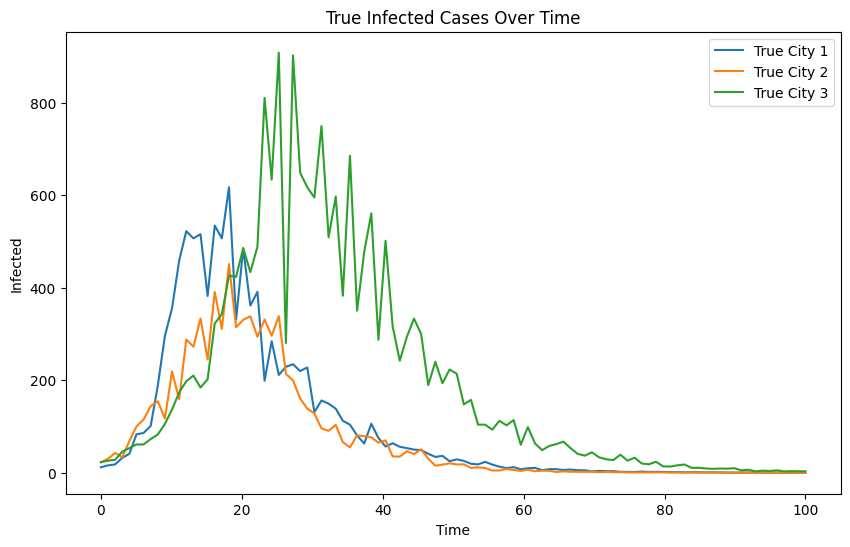

In [ ]:
# Plot the true infected cases over time for each city
plt.figure(figsize=(10, 6))
for city in range(num_cities):
    plt.plot(time_points.numpy(), synthetic_outages_noisy[:, city, 1].numpy(), label=f"True City {city+1}")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.title("True Infected Cases Over Time")
plt.show()

In [ ]:
def plot_true_infected(time_points, synthetic_outages, customer_tensor, city_indices, title):
    """
    Plots the true infected cases over time for each city, including SAIDI in the legend,
    and adds a light blue shaded area under the curve.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
        city_indices (list): List of city indices to plot.
        title (str): Title of the plot.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    for city in city_indices:
        # Extract true infected cases for the city
        outage_true = synthetic_outages[:, city, 1].numpy()
        time = time_points.numpy()
        customer = customer_tensor[city].item()

        # Calculate SAIDI for the city
        saidi_true = np.sum(outage_true) / customer

        # Create the plot
        plt.figure(figsize=(8, 6))
        plt.plot(
            time,
            outage_true,
            label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
            linewidth=6,
            color='tab:blue'
        )
        # Add a light touch of blue under the plotted curve
        plt.fill_between(
            time,
            outage_true,
            color='lightblue',
            alpha=0.2
        )
        plt.xlabel("Time", fontsize=18)
        plt.ylabel("No. Outage Households", fontsize=18)
        # Set legend location to upper right
        plt.legend(fontsize=18, loc='upper right')
        # Remove the plot title (since you will add it in LaTeX)
        # plt.title(f"{title} - City {city+1}")

        # Adjust font sizes for ticks
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)

        # Add lighter grid lines
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

        # Tight layout to minimize white space
        plt.tight_layout()

        # Save the plot to a PDF file (optional)
        filename = f"city_{city+1}_true_infected.pdf"
        plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Plot saved to {filename}")

        # Show the plot
        plt.show()

        # Close the figure to free memory
        plt.close()


Plot saved to city_1_true_infected.pdf


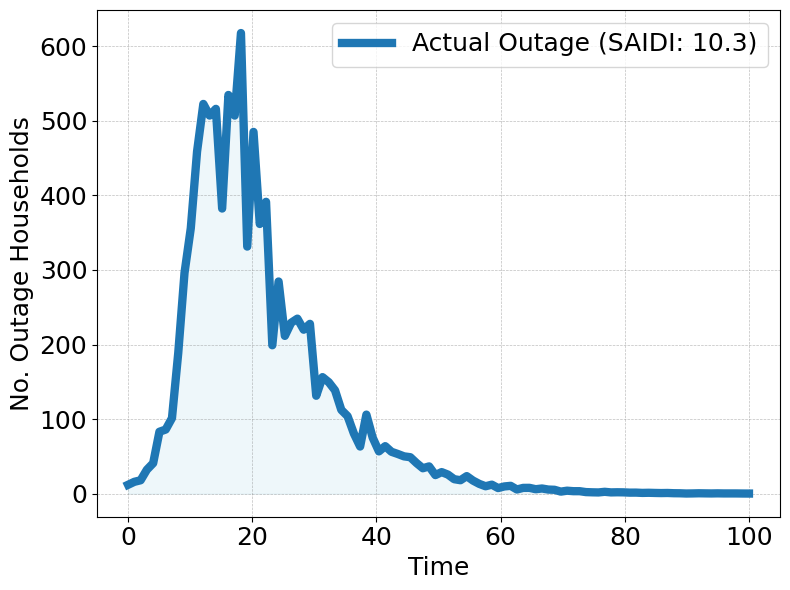

Plot saved to city_2_true_infected.pdf


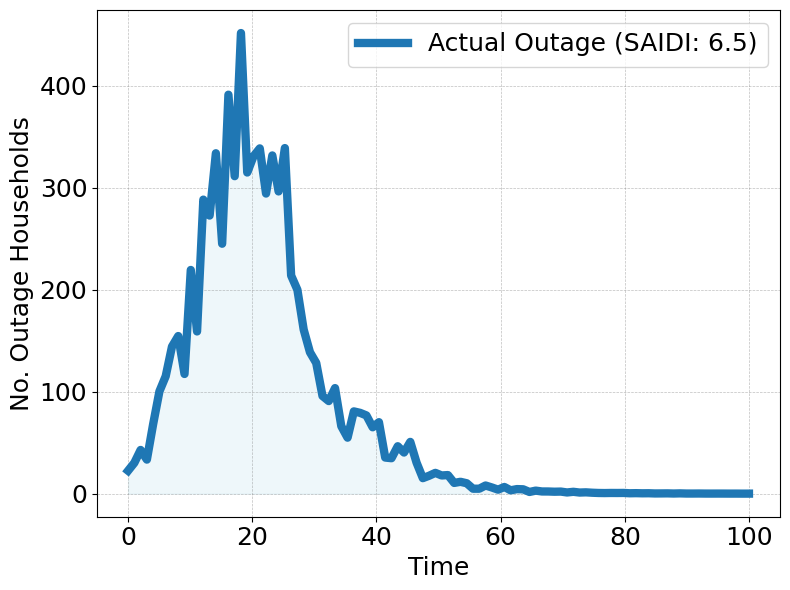

Plot saved to city_3_true_infected.pdf


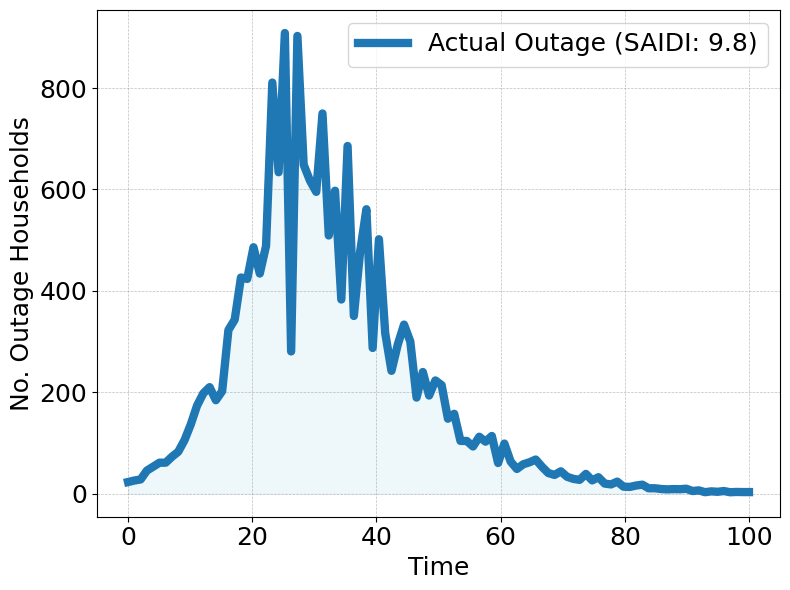

In [ ]:
# Plot the true infected cases over time for each city using the function
customer_tensor = total_households  # Total customers for each city
plot_true_infected(time_points, synthetic_outages_noisy, customer_tensor, city_indices=range(num_cities), title="True Infected Cases Over Time with Noise")


In [ ]:
# Step 2: Run a SIR model with wind input to predict the outage, using MSE error for both cities
# Generate wind speed data for each city
def generate_wind_speed(time_points, num_cities):
    wind_speeds = []
    for city in range(num_cities):
        base_wind_speed = torch.tensor(10.0)
        amplitude = torch.tensor(5.0)
        frequency = torch.tensor(0.1)
        phase_shift = torch.tensor(city * np.pi / num_cities)
        wind_speed_city = base_wind_speed + amplitude * torch.sin(frequency * time_points + phase_shift)
        wind_speeds.append(wind_speed_city)
    wind_speeds = torch.stack(wind_speeds, dim=1)  # Shape: (len(time_points), num_cities)
    return wind_speeds

wind_speeds = generate_wind_speed(time_points, num_cities)

# Neural network that predicts beta and gamma from wind speed
class BetaGammaNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_cities):
        super(BetaGammaNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)
        self.relu = torch.nn.ReLU()
        # Output beta and gamma for each city
        self.fc2 = torch.nn.Linear(hidden_size, num_cities * 2)  # Outputs beta and gamma for each city

    def forward(self, wind_speed_t):
        # wind_speed_t: tensor of shape (num_cities,)
        x = self.fc1(wind_speed_t)
        x = self.relu(x)
        x = self.fc2(x)
        beta_gamma = torch.nn.functional.softplus(x)  # Ensure beta and gamma are positive
        beta = beta_gamma[:num_cities]
        gamma = beta_gamma[num_cities:]
        return beta, gamma

# Define the SIR model with neural network for beta and gamma
class WindSIRModel(torch.nn.Module):
    def __init__(self, beta_gamma_nn, wind_speeds, time_points):
        super(WindSIRModel, self).__init__()
        self.beta_gamma_nn = beta_gamma_nn  # Neural network that predicts beta and gamma
        self.wind_speeds = wind_speeds  # Shape: (len(time_points), num_cities)
        self.time_points = time_points  # Shape: (len(time_points),)

    def interpolate_wind_speed(self, t):
        # Interpolate wind speed at time t for each city
        t_np = t.detach().cpu().numpy()
        time_points_np = self.time_points.detach().cpu().numpy()
        wind_speeds_np = self.wind_speeds.detach().cpu().numpy()
        wind_speed_t = np.array([
            np.interp(t_np, time_points_np, wind_speeds_np[:, city])
            for city in range(self.wind_speeds.shape[1])
        ])
        wind_speed_t = torch.tensor(wind_speed_t, dtype=torch.float32)
        return wind_speed_t  # Shape: (num_cities,)

    def forward(self, t, y):
        S = y[:, 0]
        I = y[:, 1]
        R = y[:, 2]
        wind_speed_t = self.interpolate_wind_speed(t)
        beta, gamma = self.beta_gamma_nn(wind_speed_t)
        N = total_households
        dSdt = -beta * S * I / N
        dIdt = beta * S * I / N - gamma * I
        dRdt = gamma * I
        return torch.stack([dSdt, dIdt, dRdt], dim=1)


In [ ]:
# Initialize the neural network
input_size = num_cities  # Wind speed for each city
hidden_size = 16  # Can adjust as needed
beta_gamma_nn = BetaGammaNN(input_size, hidden_size, num_cities)

# Initialize the WindSIRModel
wind_sir_model = WindSIRModel(beta_gamma_nn, wind_speeds, time_points)

# Define optimizer and loss function
optimizer = torch.optim.Adam(beta_gamma_nn.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss()

# Training loop with MSE loss
num_epochs = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    pred_outages = odeint(wind_sir_model, initial_conditions, time_points)
    loss = loss_fn(pred_outages, synthetic_outages_noisy)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % (num_epochs//10) == 0:
        print(f"MSE Training - Epoch [{epoch + 1}/{num_epochs}], MSE Loss: {loss.item():.4f}")


MSE Training - Epoch [10/100], MSE Loss: 104724.6641
MSE Training - Epoch [20/100], MSE Loss: 95835.3438
MSE Training - Epoch [30/100], MSE Loss: 43107.4805
MSE Training - Epoch [40/100], MSE Loss: 46846.1914
MSE Training - Epoch [50/100], MSE Loss: 40357.9336
MSE Training - Epoch [60/100], MSE Loss: 39237.8203
MSE Training - Epoch [70/100], MSE Loss: 38231.8672
MSE Training - Epoch [80/100], MSE Loss: 37653.5586
MSE Training - Epoch [90/100], MSE Loss: 37168.5898
MSE Training - Epoch [100/100], MSE Loss: 36747.6016


In [ ]:
# Save the model parameters after MSE training
model_save_path = 'wind_sir_model.pth'
torch.save(wind_sir_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to wind_sir_model.pth


In [ ]:
# To load the model parameters later
# Create a new instance of the model (make sure the model architecture is the same)
# beta_gamma_nn_loaded = BetaGammaNN(input_size, hidden_size, num_cities)
# wind_sir_model_loaded = WindSIRModel(beta_gamma_nn_loaded, wind_speeds, time_points)
beta_gamma_nn = BetaGammaNN(input_size, hidden_size, num_cities)

# Initialize the WindSIRModel
wind_sir_model = WindSIRModel(beta_gamma_nn, wind_speeds, time_points)
# Load the saved state dictionary into the model
wind_sir_model.load_state_dict(torch.load(model_save_path))
print("Model loaded from", model_save_path)

Model loaded from wind_sir_model.pth


<ipython-input-323-cc0e96abc663>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wind_sir_model.load_state_dict(torch.load(model_save_path))


In [ ]:
pred_outages = odeint(wind_sir_model, initial_conditions, time_points)

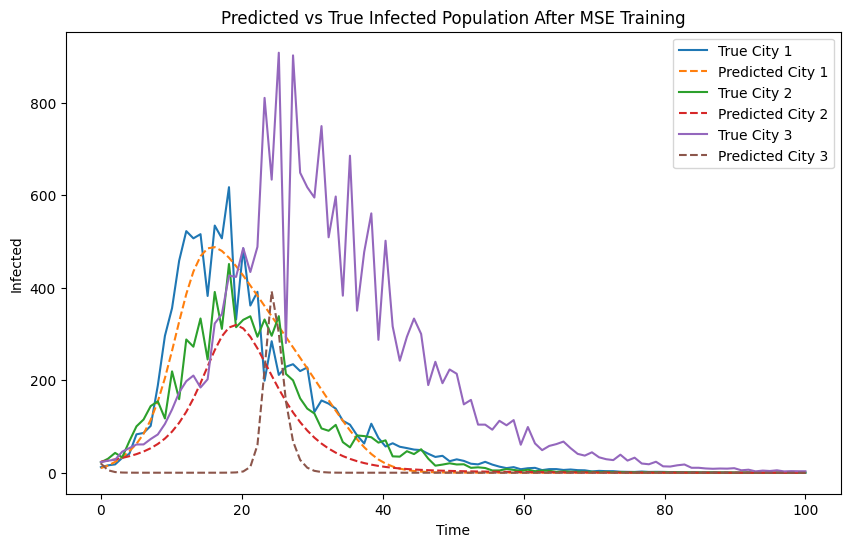

In [ ]:
# Save the model parameters after MSE training
mse_model_state_dict = beta_gamma_nn.state_dict()

# Plot predictions vs true data after MSE training
plt.figure(figsize=(10, 6))
for city in range(num_cities):
    plt.plot(time_points.numpy(), synthetic_outages_noisy[:, city, 1].numpy(), label=f"True City {city+1}")
    plt.plot(time_points.numpy(), pred_outages[:, city, 1].detach().numpy(), linestyle='--', label=f"Predicted City {city+1}")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.title("Predicted vs True Infected Population After MSE Training")
plt.show()

In [ ]:
def plot_predictions(
    time_points, synthetic_outages, pred_outages, customer_tensor, city_indices, save_flag=True, filename_suffix="", align_y=True
):
    """
    Plots the true and predicted outages for each city, highlighting areas where predictions overestimate or underestimate the actual outages.
    Saves each plot as a PDF file.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
        customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
        city_indices (list): List of city indices to plot.
        save_flag (bool): Whether to save the plots. Defaults to True.
        filename_suffix (str): Suffix to append to the filename. Defaults to "".
        align_y (bool): Whether to align the y-axis across all plots. Defaults to True.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    # Determine the global maximum outage value across all cities if alignment is desired
    if align_y:
        outage_true_all = synthetic_outages[:, city_indices, 1]
        outage_pred_all = pred_outages[:, city_indices, 1]
        max_outage_true = torch.max(outage_true_all).item()
        max_outage_pred = torch.max(outage_pred_all).item()
        global_max = max(max_outage_true, max_outage_pred)
        y_max = global_max * 1.3  # Adding 10% padding for better visualization

    for idx, city in enumerate(city_indices):
        # Extract data for the city
        time = time_points.numpy()
        outage_true = synthetic_outages[:, city, 1].numpy()
        outage_pred = pred_outages[:, city, 1].detach().numpy()
        customer = customer_tensor[city].item()

        # Calculate SAIDI and MSE
        saidi_true = np.sum(outage_true) / customer
        saidi_pred = np.sum(outage_pred) / customer
        mse_value = np.mean((outage_pred - outage_true) ** 2)

        # Determine y-axis maximum for the current plot
        if not align_y:
            current_max = max(np.max(outage_true), np.max(outage_pred))
            y_max_current = current_max * 1.1  # Adding 10% padding
        else:
            y_max_current = y_max

        # Create the plot
        plt.figure(figsize=(10, 9))

        # Add a light touch of grey under the plotted curve
        plt.fill_between(
            time,
            outage_true,
            color="grey",
            alpha=0.2,
            label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
        )

        # Plot the predicted outage
        plt.plot(
            time,
            outage_pred,
            label=f"MSE Model Pred.\n(SAIDI: {saidi_pred:.1f}, MSE: {mse_value:.1f})",
            linewidth=6,
            linestyle="--",
            color="tab:red",
        )

        # Set labels and ticks
        plt.xlabel("Time", fontsize=32)
        if idx == 0:
            plt.ylabel("# of Outages", fontsize=32)
            # Customize the y-ticks to show every 200 units
            y_ticks = np.arange(0, y_max_current + 1, 200)
            plt.yticks(y_ticks, fontsize=32)
        else:
            # Make y-axis label and ticks transparent for city 2 and 3
            plt.ylabel("# of Outages", fontsize=32, color="white", alpha=0)  # Transparent label
            y_ticks = np.arange(0, y_max_current + 1, 200)
            plt.yticks(y_ticks, fontsize=32, color="white", alpha=0)  # Transparent ticks

        # Keep the grid lines visible
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, color="grey", alpha=0.5)

        # Set y-axis limit
        plt.ylim(0, y_max_current)

        # Set legend location
        plt.legend(fontsize=32, loc="upper right", fancybox=False)

        # Adjust font sizes for x-axis ticks
        plt.xticks(fontsize=32)

        # Tight layout to minimize white space
        plt.tight_layout()

        if save_flag:
            # Save the plot to a PDF file with the custom suffix
            filename = f"city_{city + 1}_{filename_suffix}.pdf"
            plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
            print(f"Plot saved to {filename}")

        # Show the plot
        plt.show()

        # Close the figure to free memory
        plt.close()



# def plot_predictions(time_points, synthetic_outages, pred_outages, customer_tensor, city_indices, save_flag = True, filename_suffix = ""):
#     """
#     Plots the true and predicted outages for each city, including SAIDI and MSE in the legend.
#     Saves each plot as a PDF file.

#     Args:
#         time_points (torch.tensor): Time points used in simulation.
#         synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
#         pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
#         customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
#         city_indices (list): List of city indices to plot.
#     """
#     import matplotlib.pyplot as plt
#     import numpy as np

#     for city in city_indices:
#         # Extract data for the city
#         time = time_points.numpy()
#         outage_true = synthetic_outages[:, city, 1].numpy()
#         outage_pred = pred_outages[:, city, 1].detach().numpy()
#         customer = customer_tensor[city].item()

#         # Calculate SAIDI and MSE
#         saidi_true = np.sum(outage_true) / customer
#         saidi_pred = np.sum(outage_pred) / customer
#         mse_value = np.mean((outage_pred - outage_true) ** 2)

#         # Create the plot
#         plt.figure(figsize=(8, 6))

#         # Plot the actual outage with shaded area
#         plt.plot(
#             time,
#             outage_true,
#             # label=f"Actual Outage (SAIDI: {saidi_true:.2f})",
#             label=f"Actual Outage",
#             linewidth=8,
#             color='tab:blue'
#         )
#         plt.fill_between(
#             time,
#             outage_true,
#             color='lightblue',
#             alpha=0.2
#         )

#         # Plot the predicted outage with shaded area
#         plt.plot(
#             time,
#             outage_pred,
#             label=f"Predicted Outage\n(SAIDI: {saidi_pred:.1f}, MSE: {mse_value:.1f})",
#             linewidth=8,
#             linestyle='--',
#             color='tab:orange'
#         )
#         plt.fill_between(
#             time,
#             outage_pred,
#             color='navajowhite',
#             alpha=0.4
#         )

#         plt.xlabel("Time", fontsize=20)
#         plt.ylabel("No. Outage Households", fontsize=18)
#         # Set legend location to upper right
#         plt.legend(fontsize=25, loc='upper right')

#         # Adjust font sizes for ticks
#         plt.xticks(fontsize=20)
#         plt.yticks(fontsize=20)

#         # Add lighter grid lines
#         plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

#         # Tight layout to minimize white space
#         plt.tight_layout()

#         if save_flag:
#             # Save the plot to a PDF file with the custom suffix
#             filename = f"city_{city+1}_{filename_suffix}.pdf"
#             plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
#             print(f"Plot saved to {filename}")


#         # Show the plot
#         plt.show()

#         # Close the figure to free memory
#         plt.close()

# def plot_predictions(time_points, synthetic_outages, pred_outages, customer_tensor, city_indices):
#     """
#     Plots the true and predicted outages for each city, including SAIDI and MSE in the legend.
#     Saves each plot as a PDF file.

#     Args:
#         time_points (torch.tensor): Time points used in simulation.
#         synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
#         pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
#         customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
#         city_indices (list): List of city indices to plot.
#     """
#     import matplotlib.pyplot as plt
#     import numpy as np

#     for city in city_indices:
#         # Extract data for the city
#         time = time_points.numpy()
#         outage_true = synthetic_outages[:, city, 1].numpy()
#         outage_pred = pred_outages[:, city, 1].detach().numpy()
#         customer = customer_tensor[city].item()

#         # Calculate SAIDI and MSE
#         saidi_true = np.sum(outage_true) / customer
#         saidi_pred = np.sum(outage_pred) / customer
#         mse_value = np.mean((outage_pred - outage_true) ** 2)

#         # Create the plot
#         plt.figure(figsize=(8, 5))

#         # Plot the actual outage with shaded area
#         plt.plot(
#             time,
#             outage_true,
#             label=f"Actual Outage (SAIDI: {saidi_true:.2f})",
#             linewidth=4,
#             color='tab:blue'
#         )
#         plt.fill_between(
#             time,
#             outage_true,
#             color='lightblue',
#             alpha=0.3
#         )

#         # Plot the predicted outage with shaded area
#         plt.plot(
#             time,
#             outage_pred,
#             label=f"Predicted Outage\n(SAIDI: {saidi_pred:.2f}, MSE: {mse_value:.2f})",
#             linewidth=4,
#             linestyle='--',
#             color='tab:orange'
#         )
#         plt.fill_between(
#             time,
#             outage_pred,
#             color='navajowhite',
#             alpha=0.3
#         )

#         plt.xlabel("Time", fontsize=18)
#         plt.ylabel("No. Outages", fontsize=18)

#         # Set legend location to the bottom, enlarge font size, and include the legend box
#         plt.legend(
#             fontsize=18,
#             loc='upper center',
#             bbox_to_anchor=(0.5, -0.15),
#             ncol=1,
#             frameon=True,  # Include the legend box
#             handleheight=2.4
#         )

#         # Adjust font sizes for ticks
#         plt.xticks(fontsize=14)
#         plt.yticks(fontsize=14)

#         # Add lighter grid lines
#         plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

#         # Adjust layout to make room for the legend at the bottom
#         plt.tight_layout()
#         plt.subplots_adjust(bottom=0.25)

#         # Save the plot to a PDF file
#         filename = f"city_{city+1}_prediction.pdf"
#         plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
#         print(f"Plot saved to {filename}")

#         # Show the plot
#         plt.show()

#         # Close the figure to free memory
#         plt.close()


Plot saved to city_1_MSE.pdf


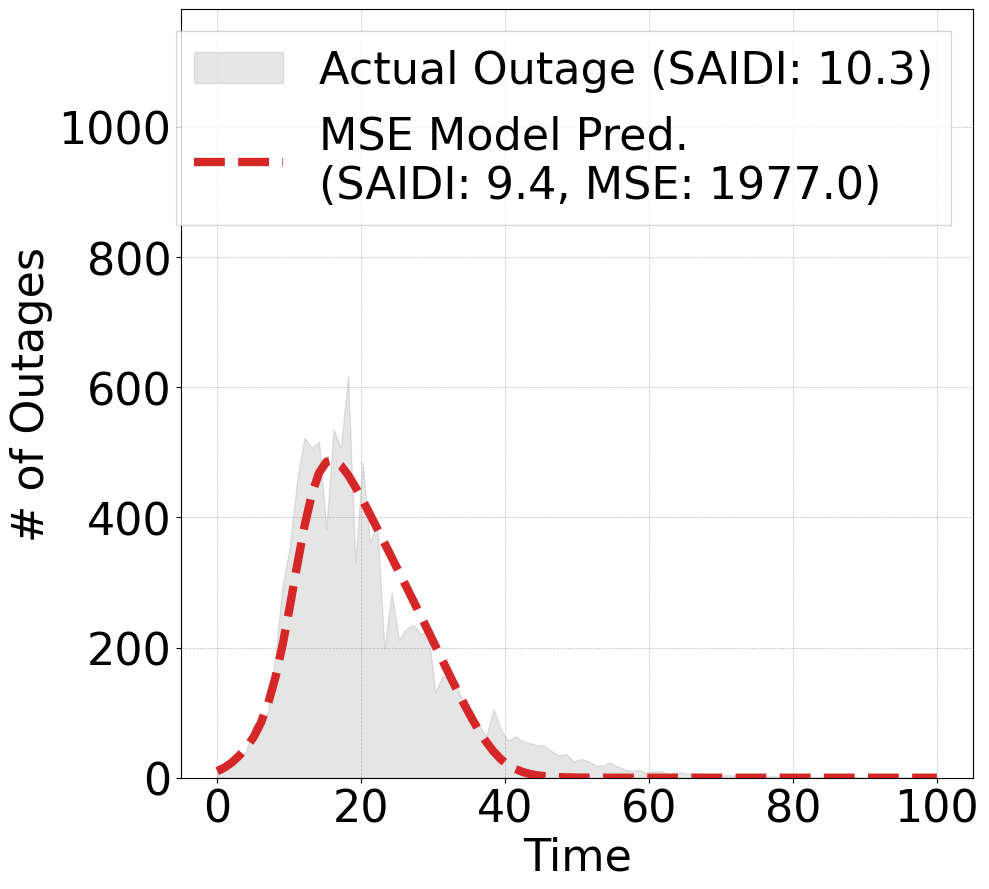

Plot saved to city_2_MSE.pdf


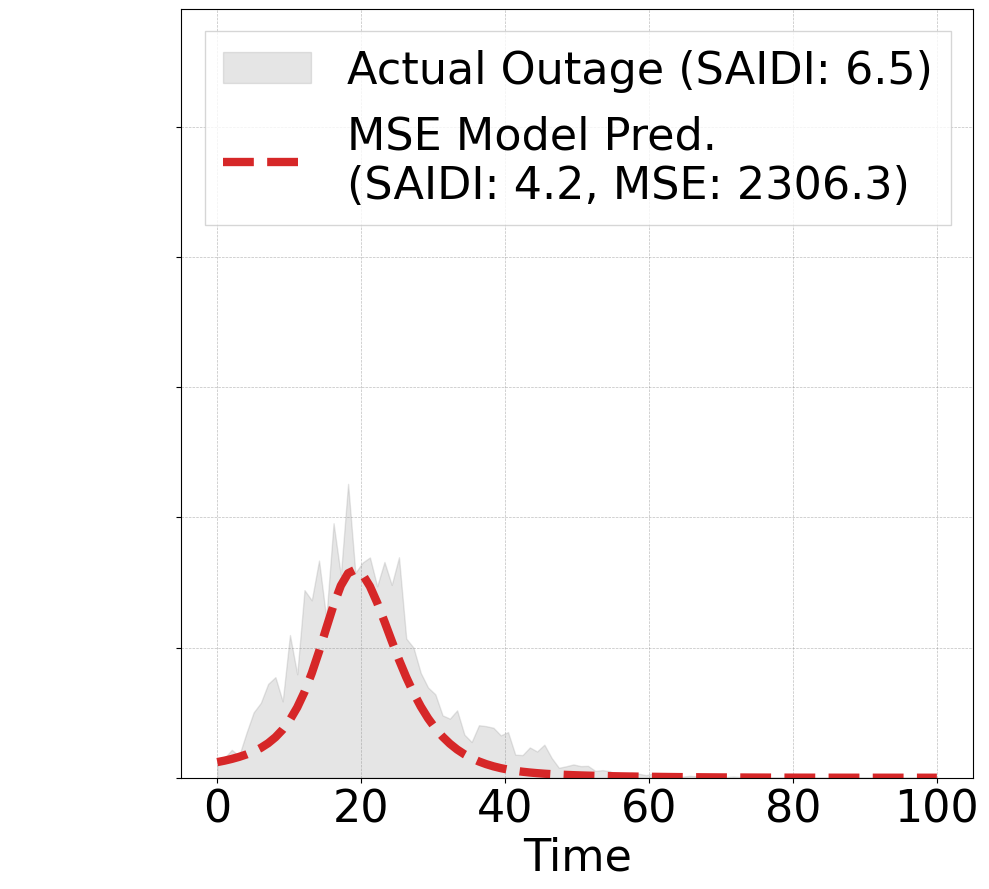

Plot saved to city_3_MSE.pdf


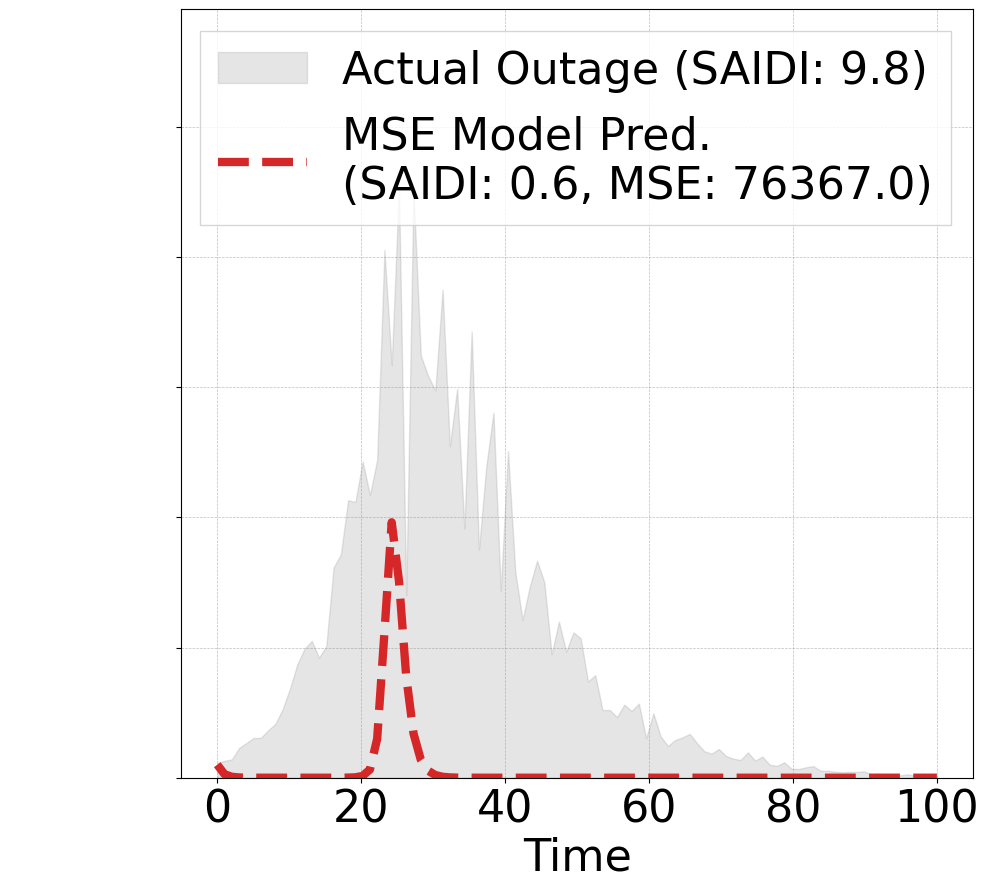

In [ ]:
# Plot predictions vs true data after MSE training using the function
plot_predictions(time_points, synthetic_outages_noisy, pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix="MSE")

In [ ]:
# # Plot predictions vs true data after MSE training using the function
# plot_predictions(time_points, synthetic_outages_noisy, mse_pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix="MSE")

In [ ]:
# # Plot predictions vs true data after MSE training using the function
# plot_predictions_diff(time_points, synthetic_outages_noisy, pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix="MSE")

In [ ]:
# Function to calculate SAIDI using torch tensors
def calc_SAIDI_torch(customer_tensor, outage_tensor):
    """
    Calculate SAIDI for each city based on customer numbers and outage data over the whole time period.

    Args:
        customer_tensor (torch.tensor): Tensor of total customer counts for each city. Shape: (num_cities,)
        outage_tensor (torch.tensor): Tensor of outage values for each city across all time steps. Shape: (num_cities, len(time_points))

    Returns:
        torch.tensor: Tensor of SAIDI values for each city. Shape: (num_cities,)
    """
    SAIDI = torch.sum(outage_tensor, dim=1) / customer_tensor
    return SAIDI


In [ ]:
def plot_aggregated_predictions(time_points, synthetic_outages, pred_outages, num_cities, title):
    """
    Plots the aggregated true and predicted outages over all cities, including overall MSE annotation.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
        num_cities (int): Number of cities.
        title (str): Title of the plot.
    """
    # Aggregate true and predicted infected cases over all cities
    true_infected = synthetic_outages[:, :, 1].sum(dim=1).numpy()  # Shape: (len(time_points),)
    pred_infected = pred_outages[:, :, 1].detach().sum(dim=1).numpy()  # Shape: (len(time_points),)

    # Calculate MSE for each city
    mse_values = []
    for city in range(num_cities):
        outage_true = synthetic_outages[:, city, 1].numpy()
        outage_pred = pred_outages[:, city, 1].detach().numpy()
        mse = np.mean((outage_pred - outage_true) ** 2)
        mse_values.append(mse)
    # Calculate overall MSE as average of MSEs
    overall_mse = np.mean(mse_values)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(time_points.numpy(), true_infected, label="Aggregated True Infected")
    plt.plot(time_points.numpy(), pred_infected, linestyle='--', label="Aggregated Predicted Infected")
    plt.xlabel("Time")
    plt.ylabel("Aggregated Infected")
    plt.legend()
    plt.title(title)

    # Add MSE annotation
    # Lower right - Overall MSE
    plt.text(0.95, 0.05, f"Overall MSE: {overall_mse:.4f}", transform=plt.gca().transAxes,
             fontsize=10, va='bottom', ha='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.show()


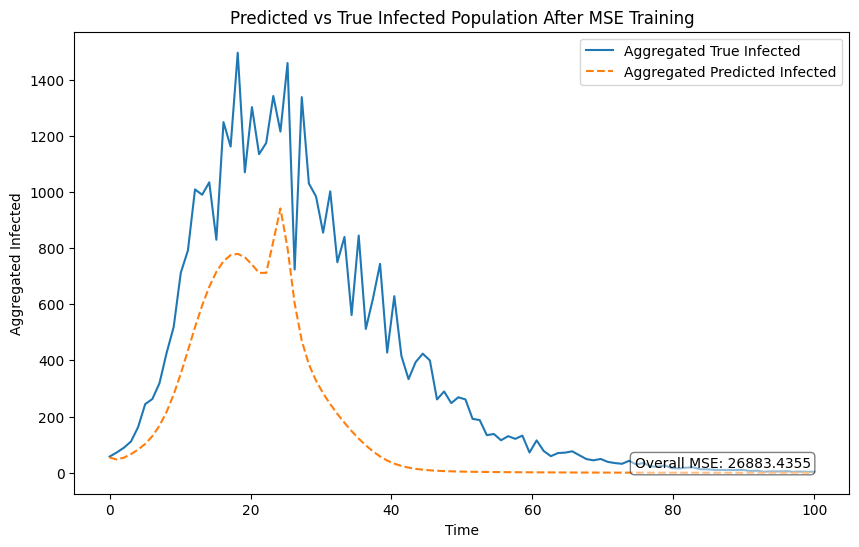

In [ ]:
plot_aggregated_predictions(time_points, synthetic_outages_noisy, pred_outages, num_cities = num_cities, title="Predicted vs True Infected Population After MSE Training")

In [ ]:
# Step 3: Use CVXPY layer to continue training the model with DFL loss
# Define the CVXPY problem
lda = 0.01
# gma = 0.001 # this works!
# gma = 0.0001 # this is more exagerated.
gma = 1


def create_cvxpy_layer(num_cities, max_investments):
    SAIDI_param = cp.Parameter(num_cities)
    x = cp.Variable(num_cities)

    objective = cp.Maximize(SAIDI_param @ x - lda * cp.sum_squares(x))
    constraints = [
        cp.sum(x) <= max_investments,
        x >= 0,
        x <= 1
    ]
    problem = cp.Problem(objective, constraints)
    assert problem.is_dpp()
    cvxpylayer = CvxpyLayer(problem, parameters=[SAIDI_param], variables=[x])
    return cvxpylayer


In [ ]:
# beta_gamma_nn = BetaGammaNN(input_size, hidden_size, num_cities)

# # Initialize the WindSIRModel
# wind_sir_model = WindSIRModel(beta_gamma_nn, wind_speeds, time_points)

DFL Training - Epoch [1/10], Decision Loss: 36726.2227, MSE Error: 36709.9062
Plot saved to city_1_DFL.pdf


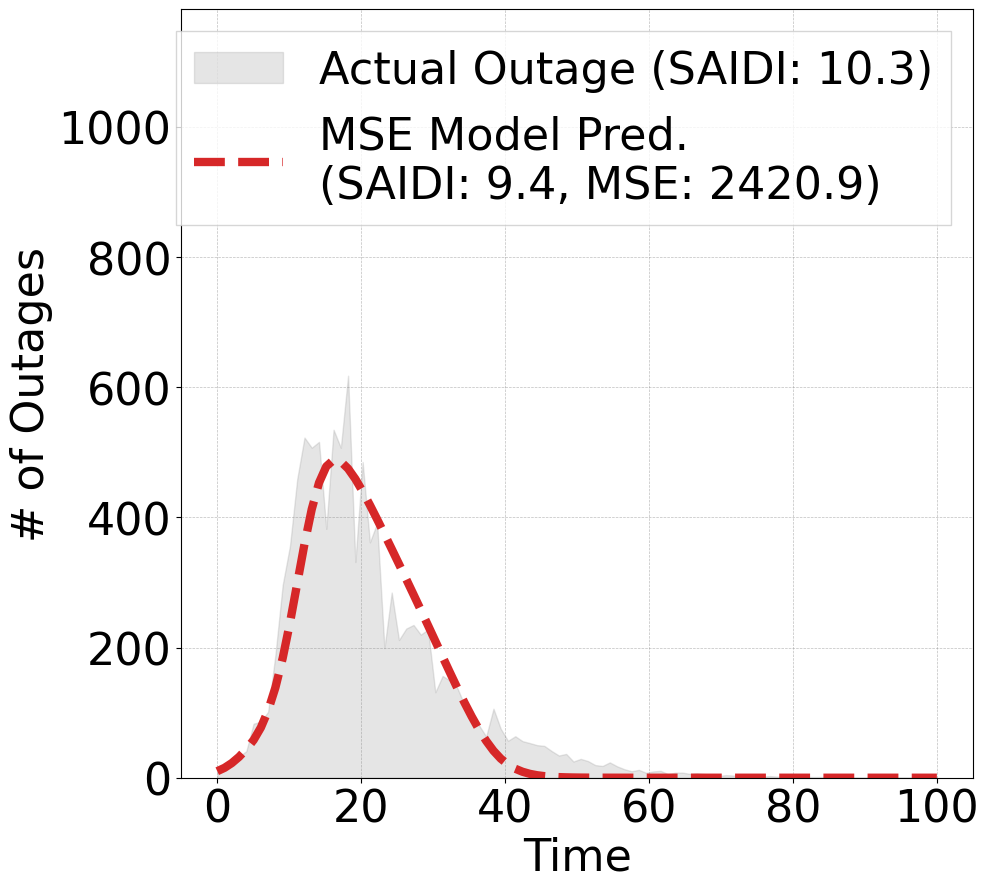

Plot saved to city_2_DFL.pdf


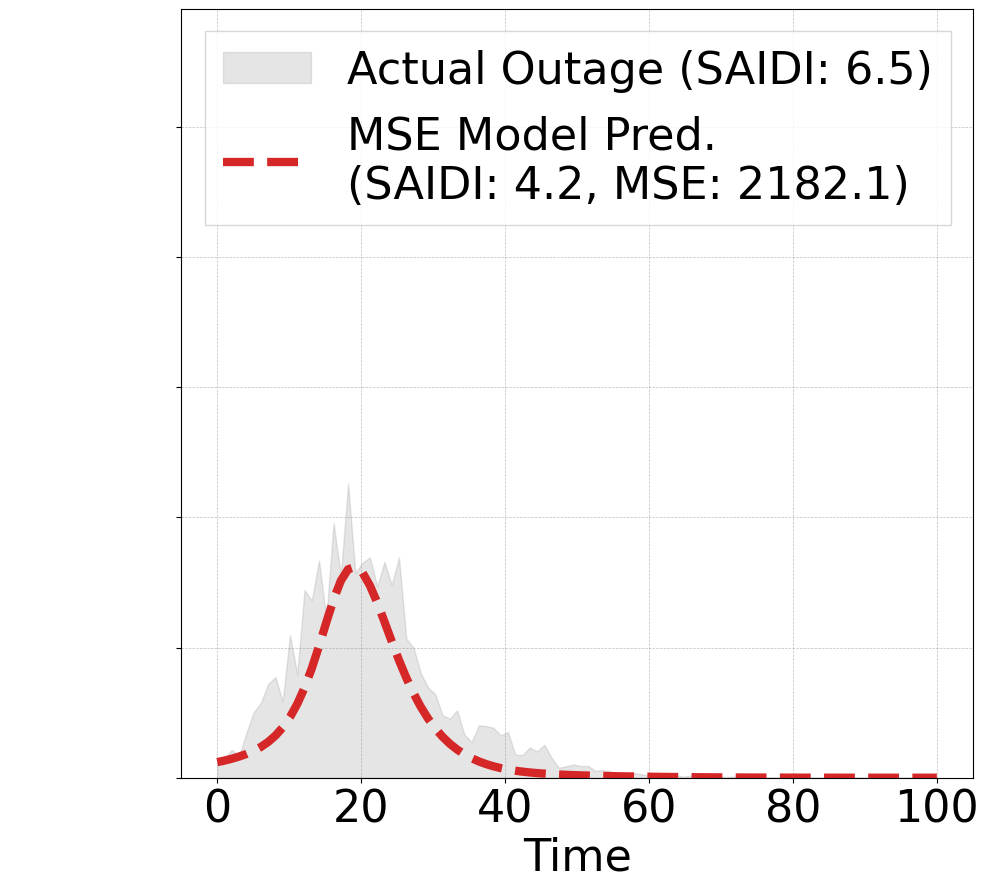

Plot saved to city_3_DFL.pdf


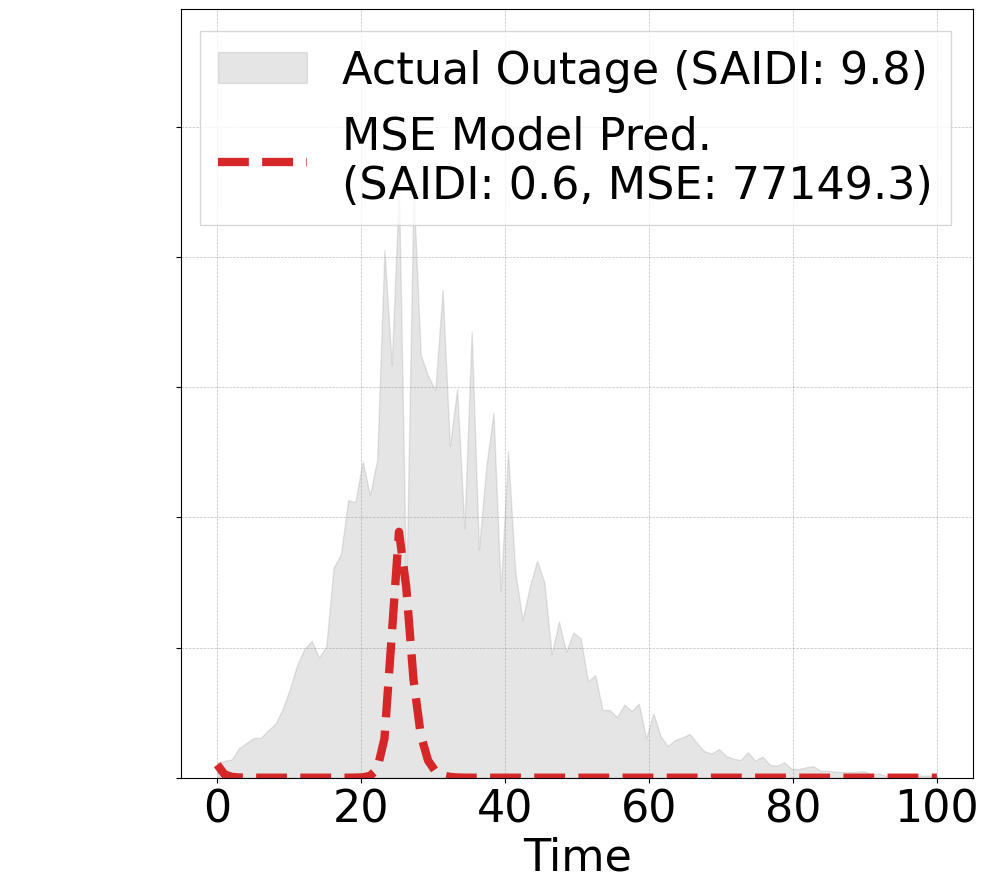

DFL Training - Epoch [2/10], Decision Loss: 36940.5195, MSE Error: 36924.2031
Plot saved to city_1_DFL.pdf


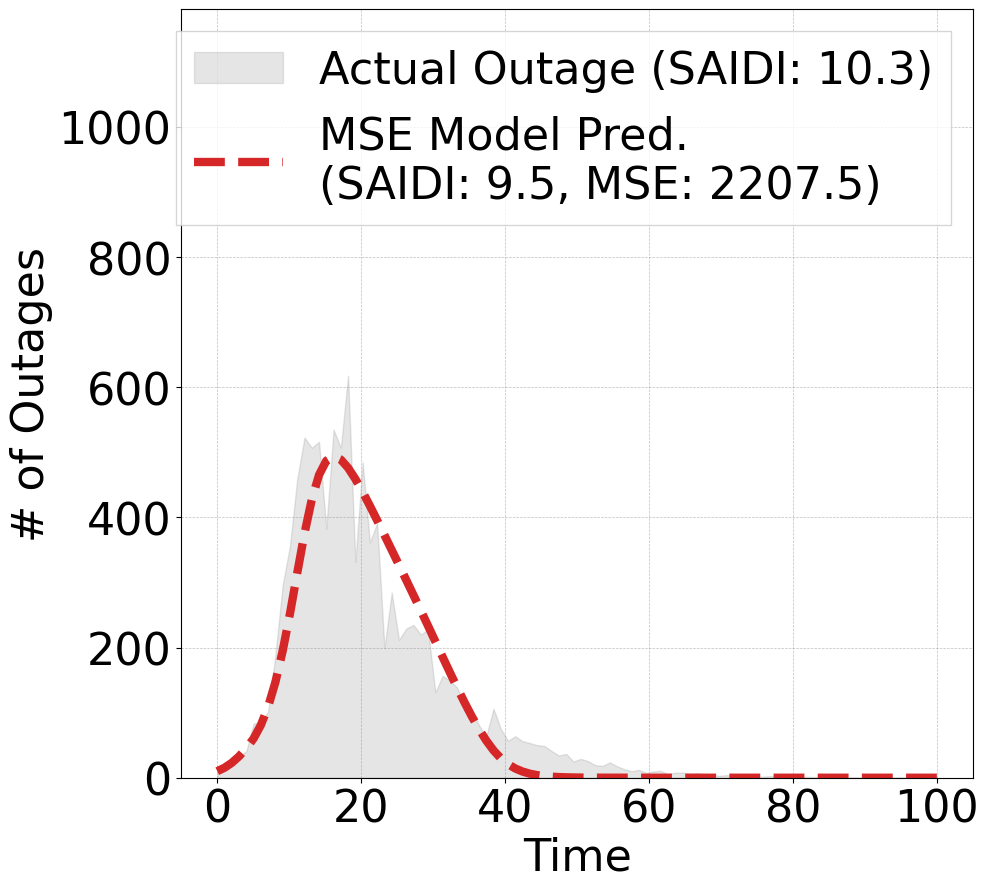

Plot saved to city_2_DFL.pdf


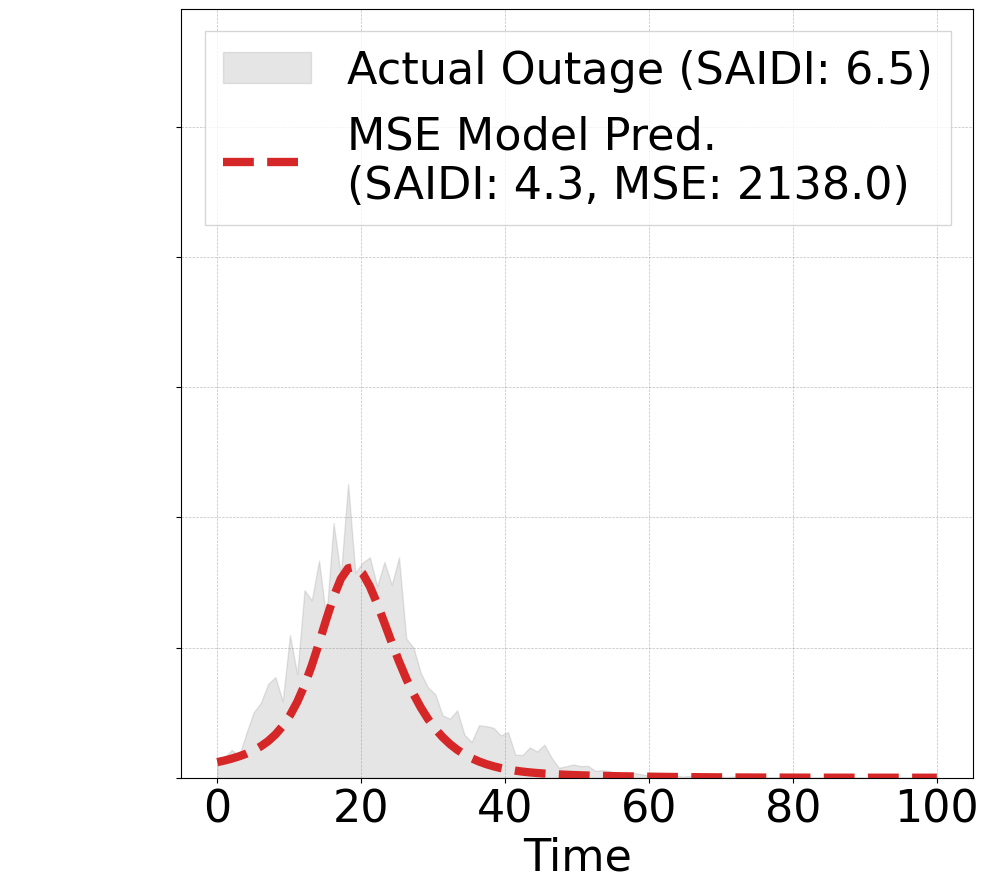

Plot saved to city_3_DFL.pdf


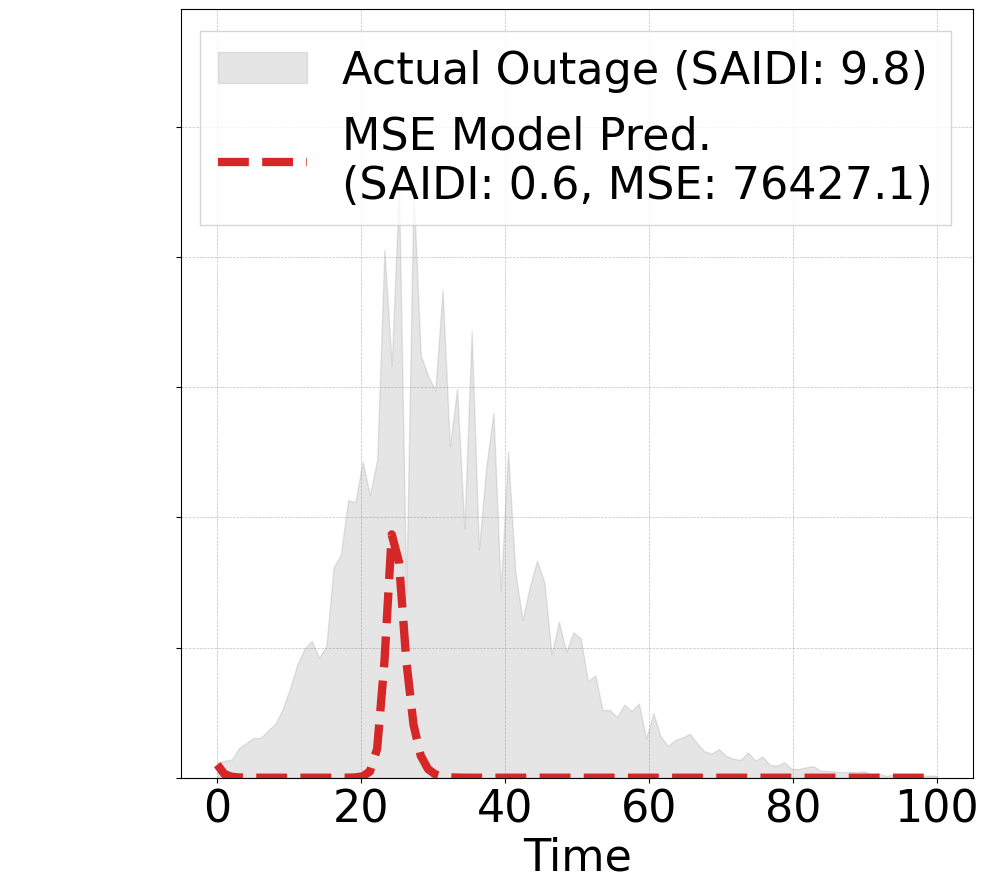

DFL Training - Epoch [3/10], Decision Loss: 36613.1211, MSE Error: 36596.8047
Plot saved to city_1_DFL.pdf


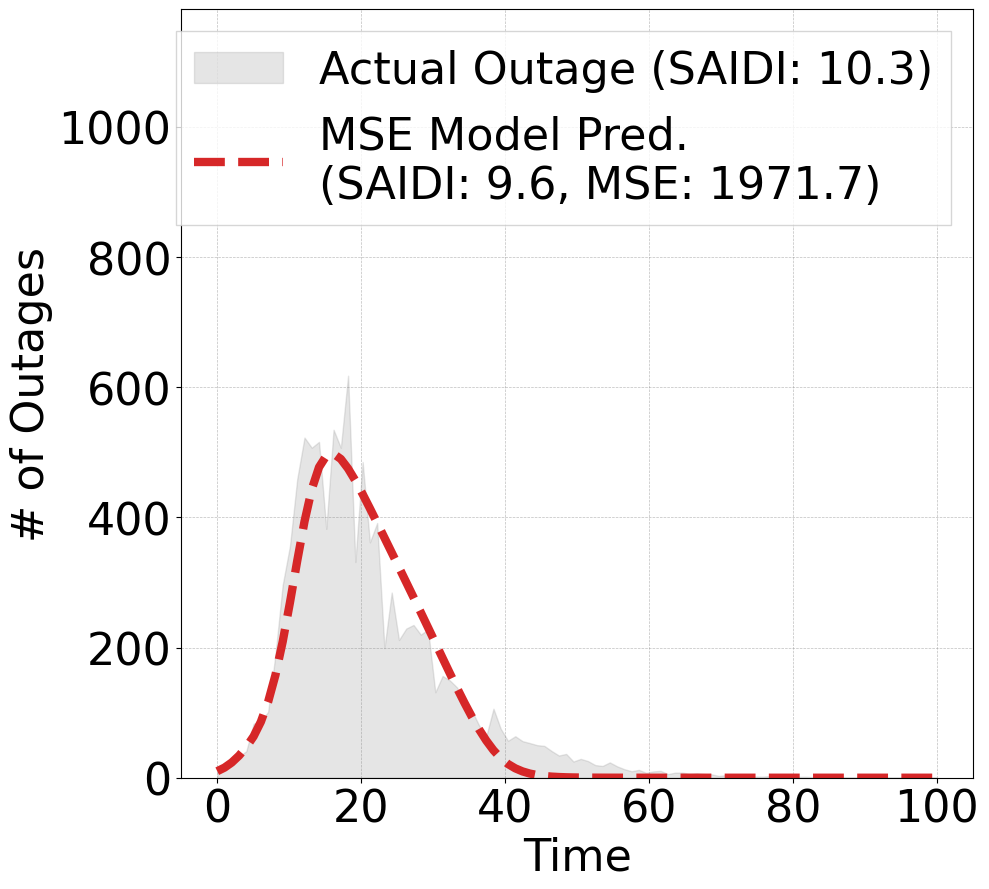

Plot saved to city_2_DFL.pdf


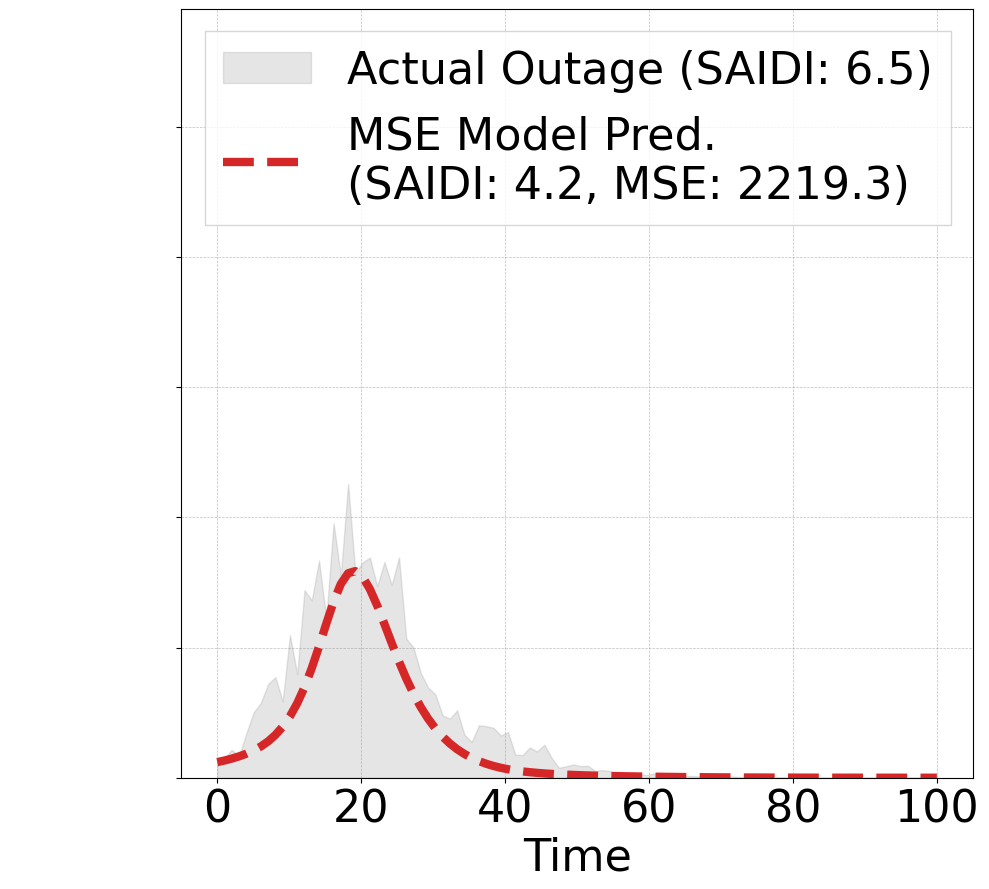

Plot saved to city_3_DFL.pdf


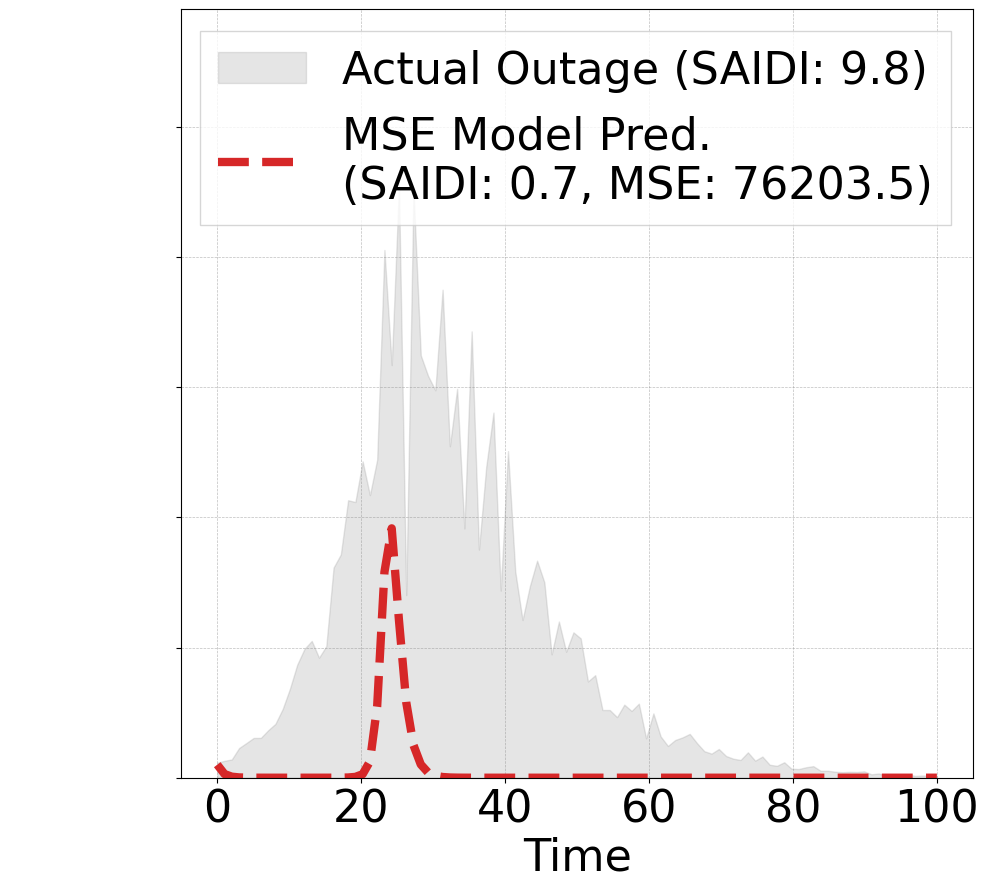

DFL Training - Epoch [4/10], Decision Loss: 36673.2930, MSE Error: 36656.9766
Plot saved to city_1_DFL.pdf


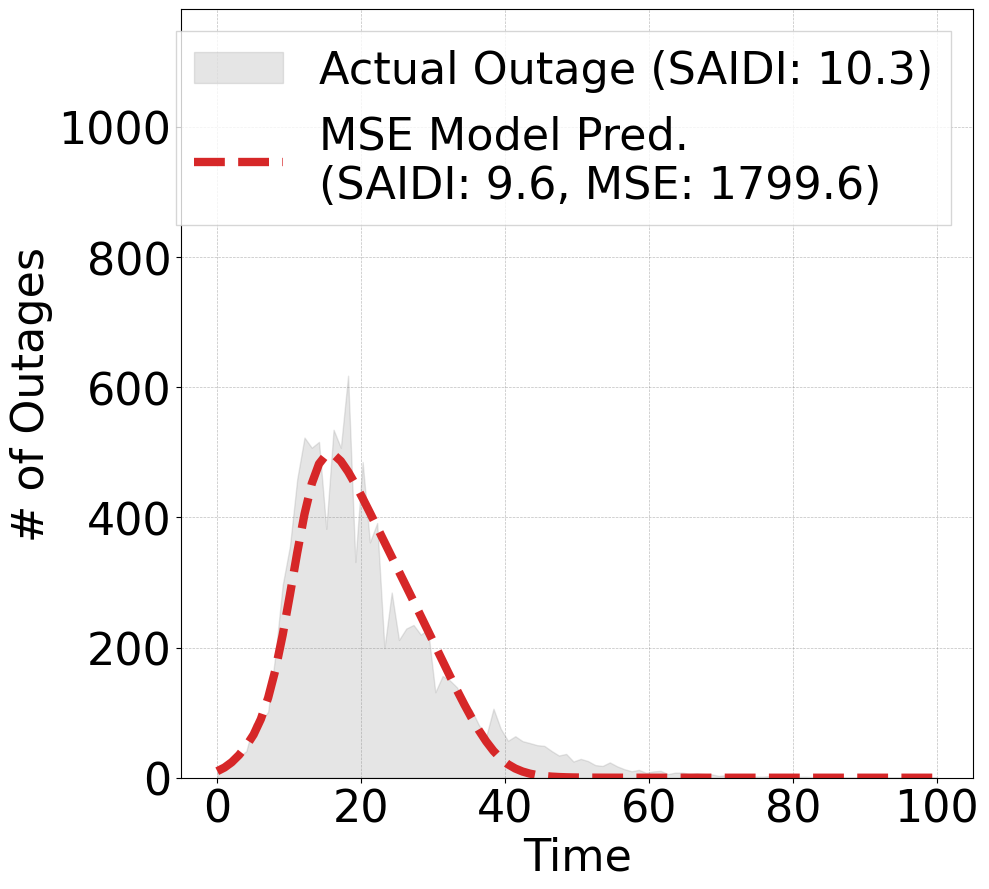

Plot saved to city_2_DFL.pdf


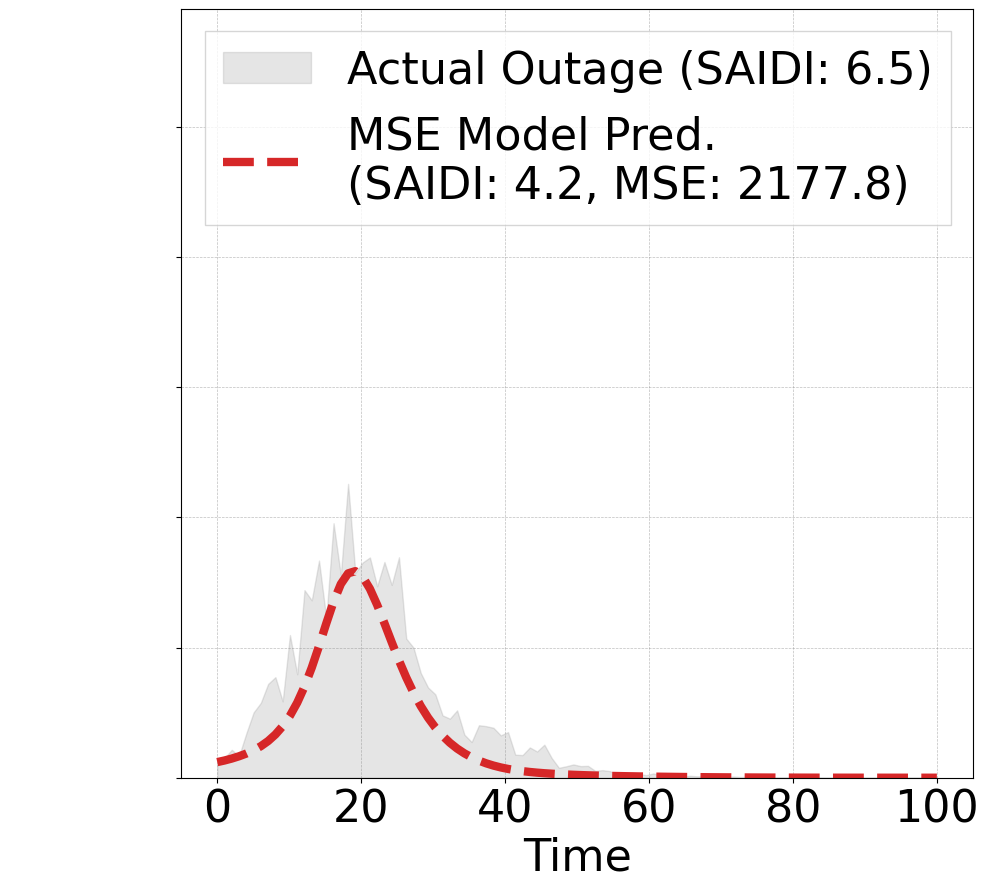

Plot saved to city_3_DFL.pdf


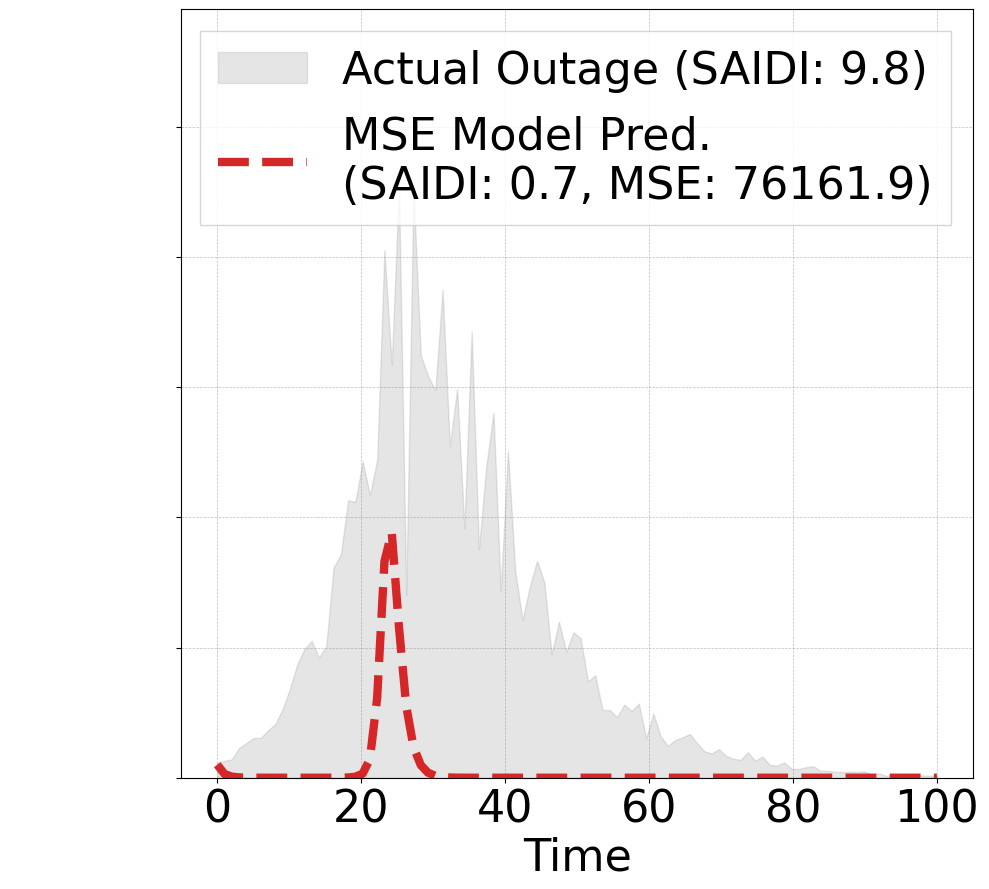

DFL Training - Epoch [5/10], Decision Loss: 36670.3555, MSE Error: 36654.0391
Plot saved to city_1_DFL.pdf


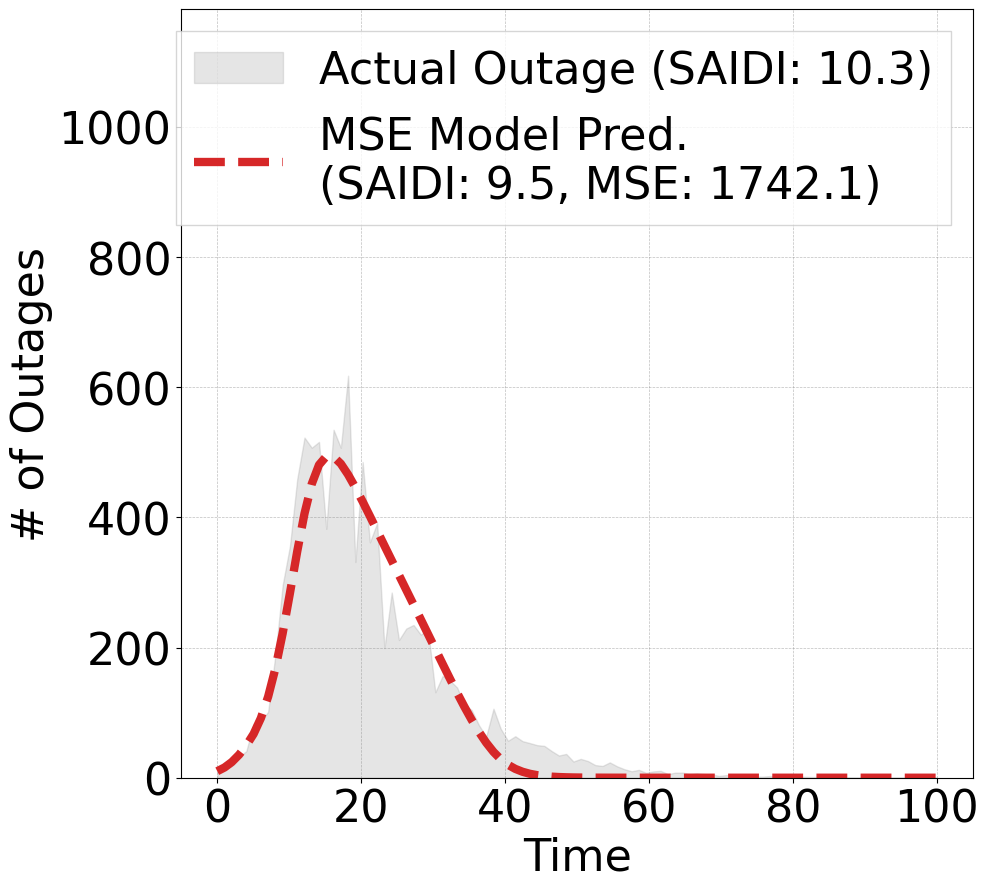

Plot saved to city_2_DFL.pdf


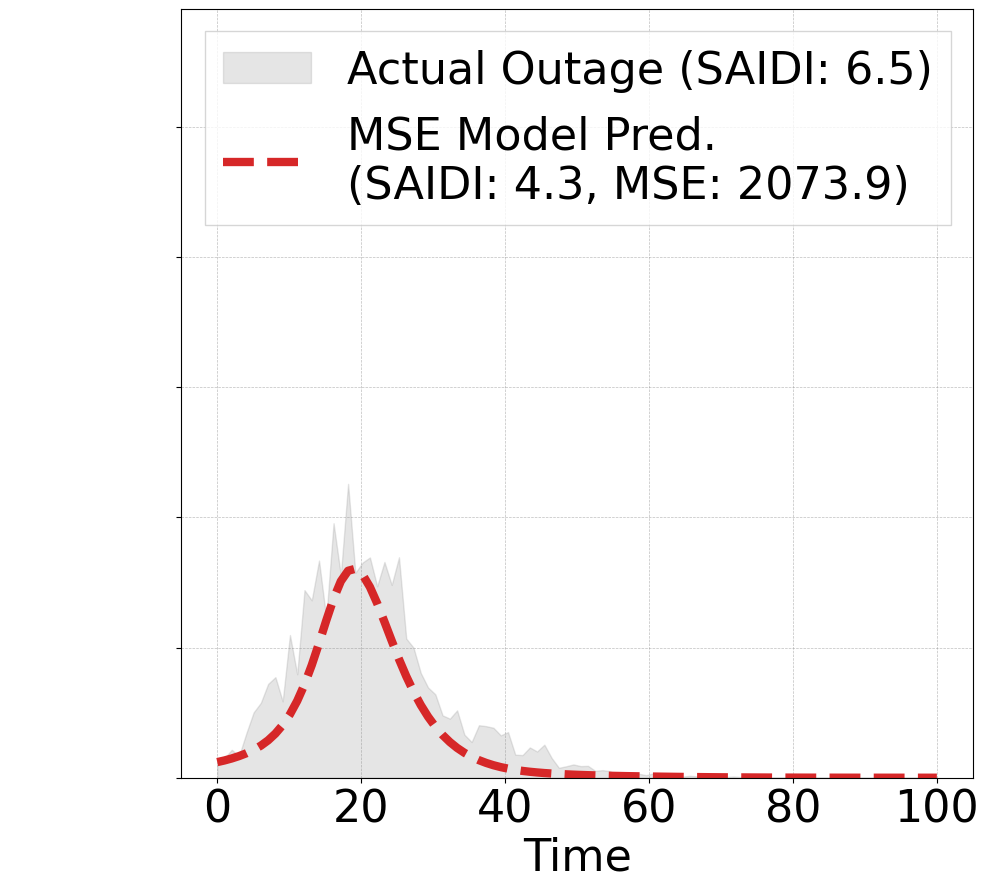

Plot saved to city_3_DFL.pdf


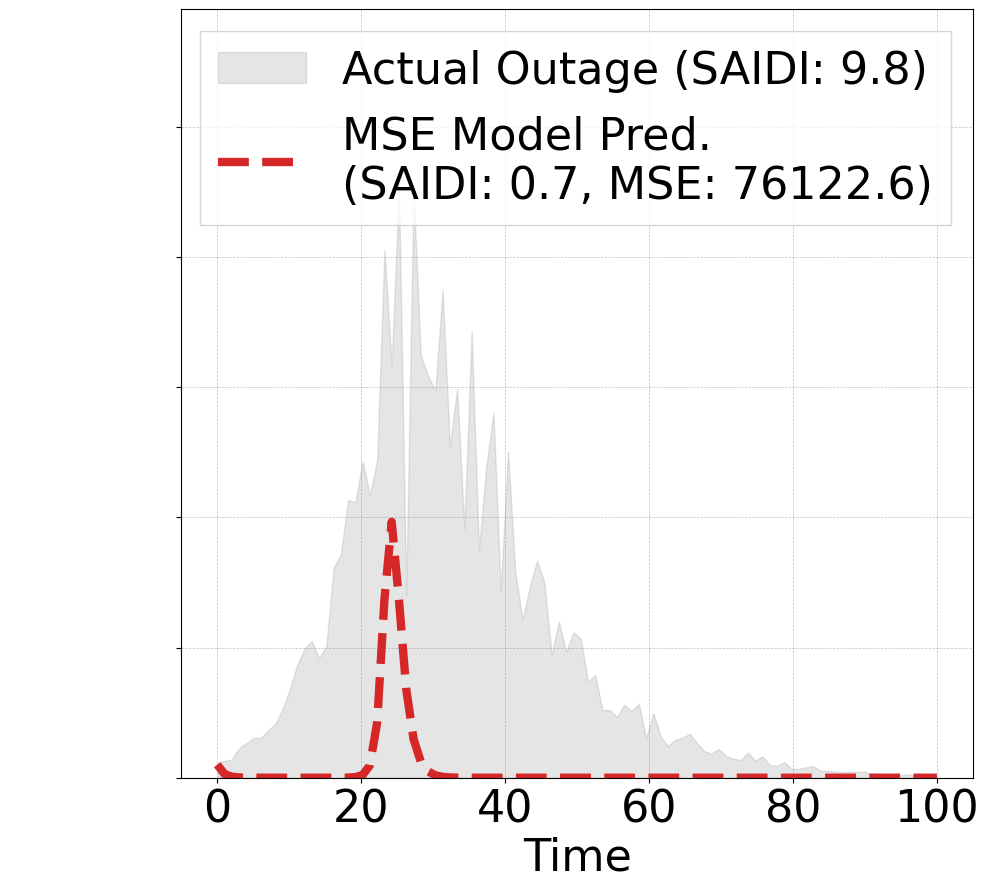

DFL Training - Epoch [6/10], Decision Loss: 36518.1797, MSE Error: 36501.8633
Plot saved to city_1_DFL.pdf


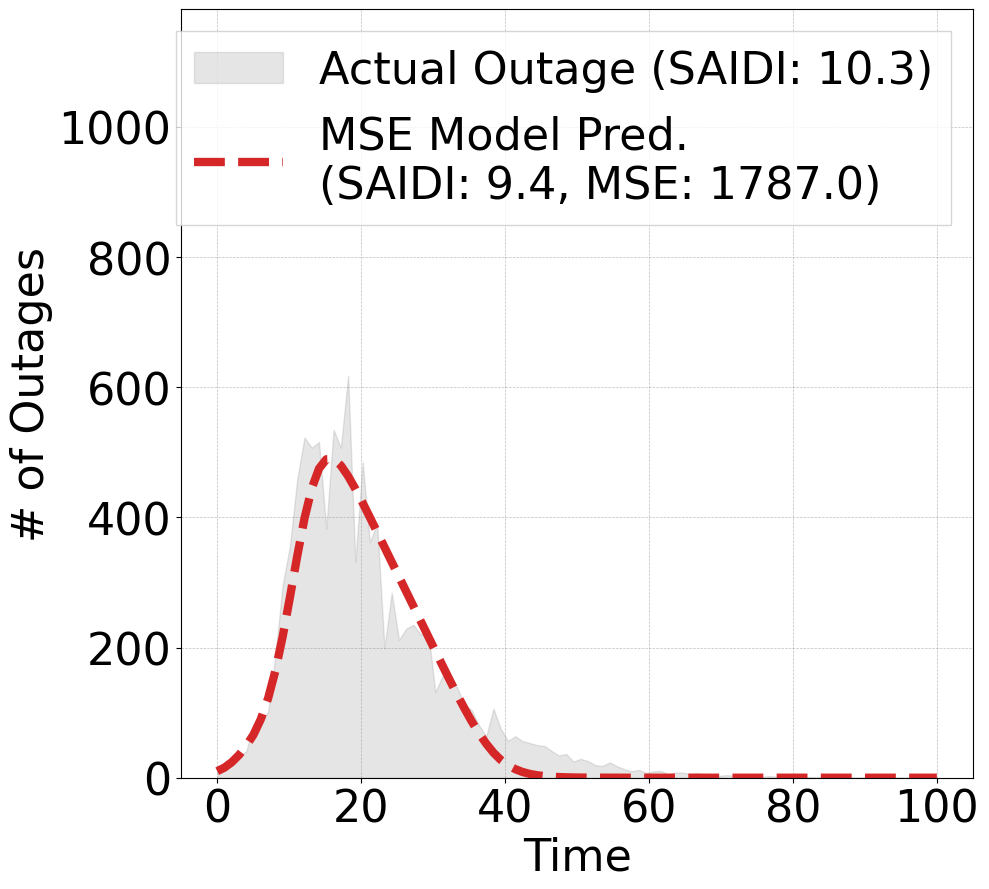

Plot saved to city_2_DFL.pdf


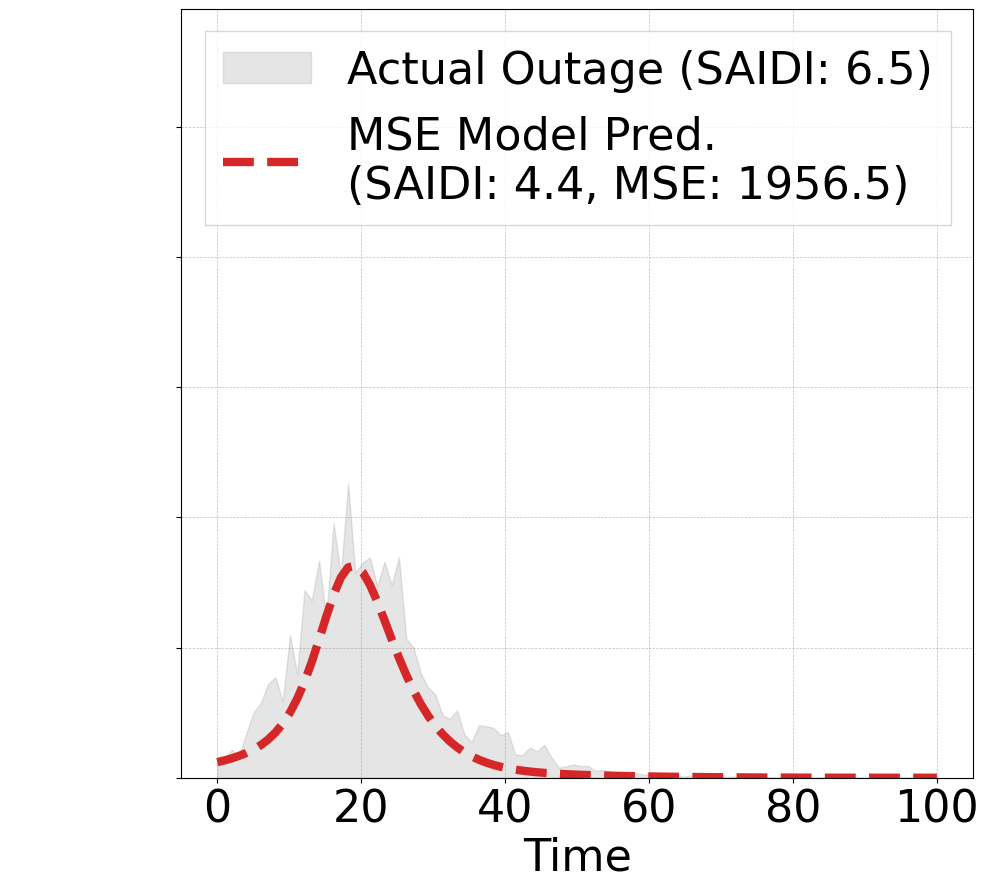

Plot saved to city_3_DFL.pdf


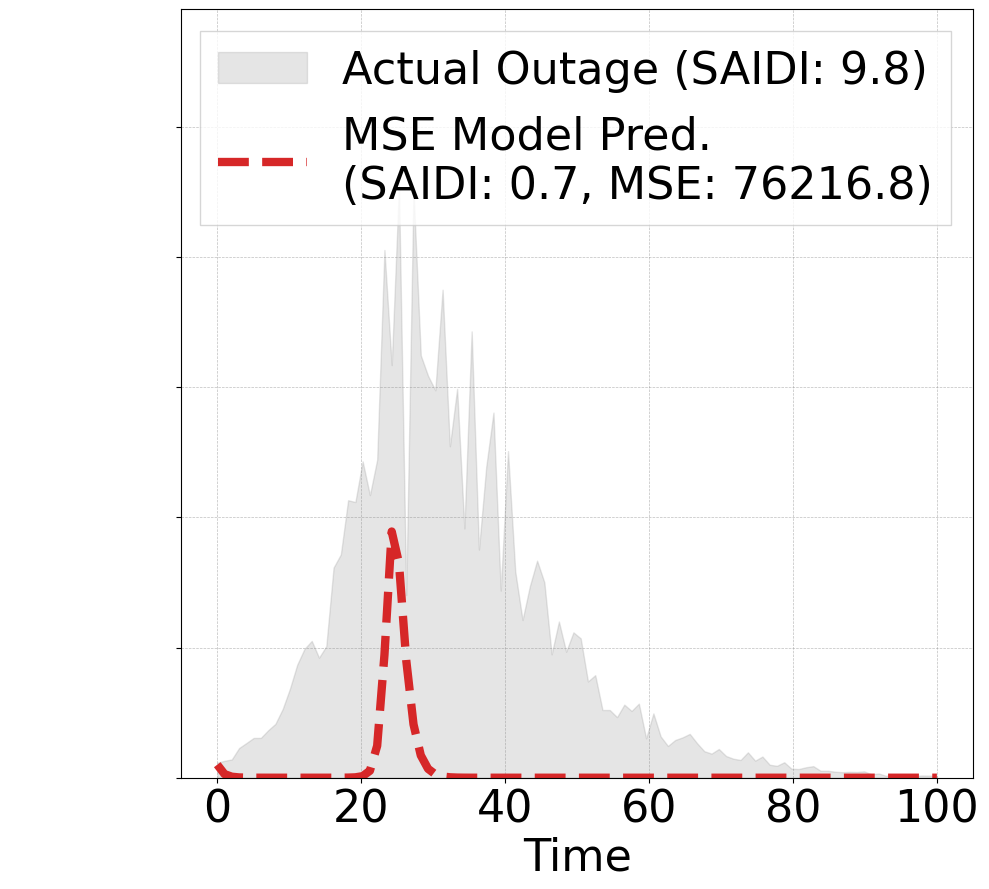

DFL Training - Epoch [7/10], Decision Loss: 36417.5703, MSE Error: 36401.2539
Plot saved to city_1_DFL.pdf


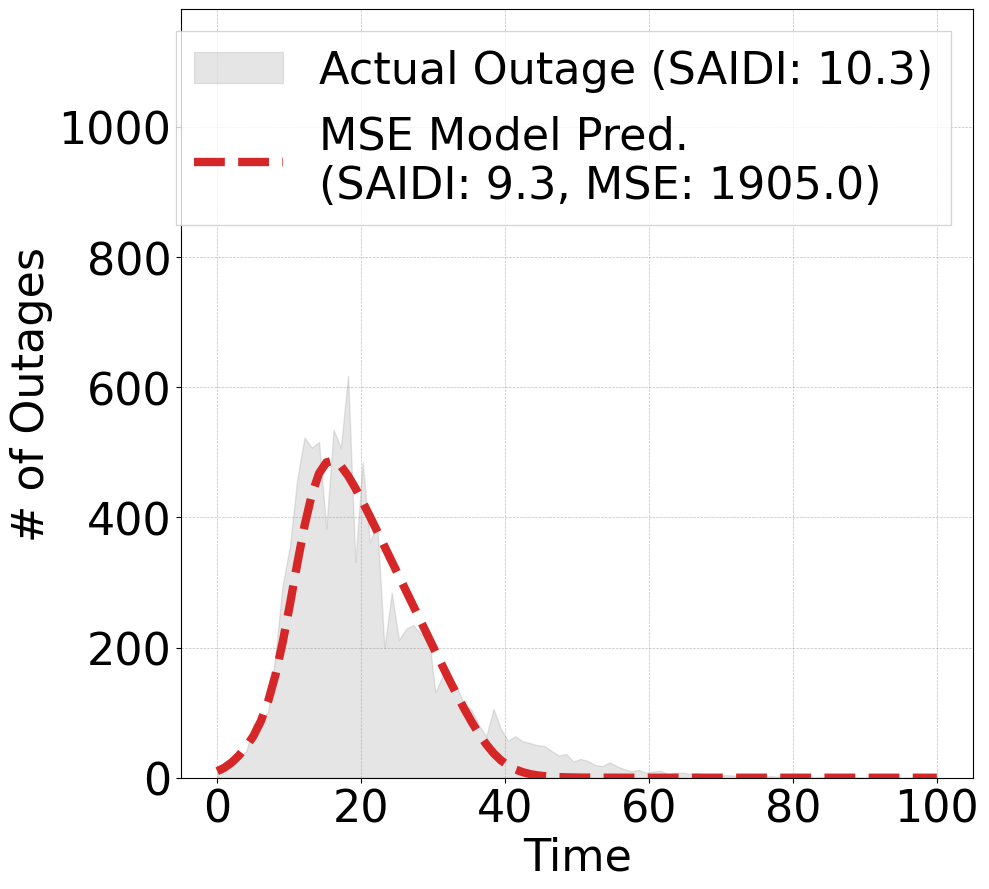

Plot saved to city_2_DFL.pdf


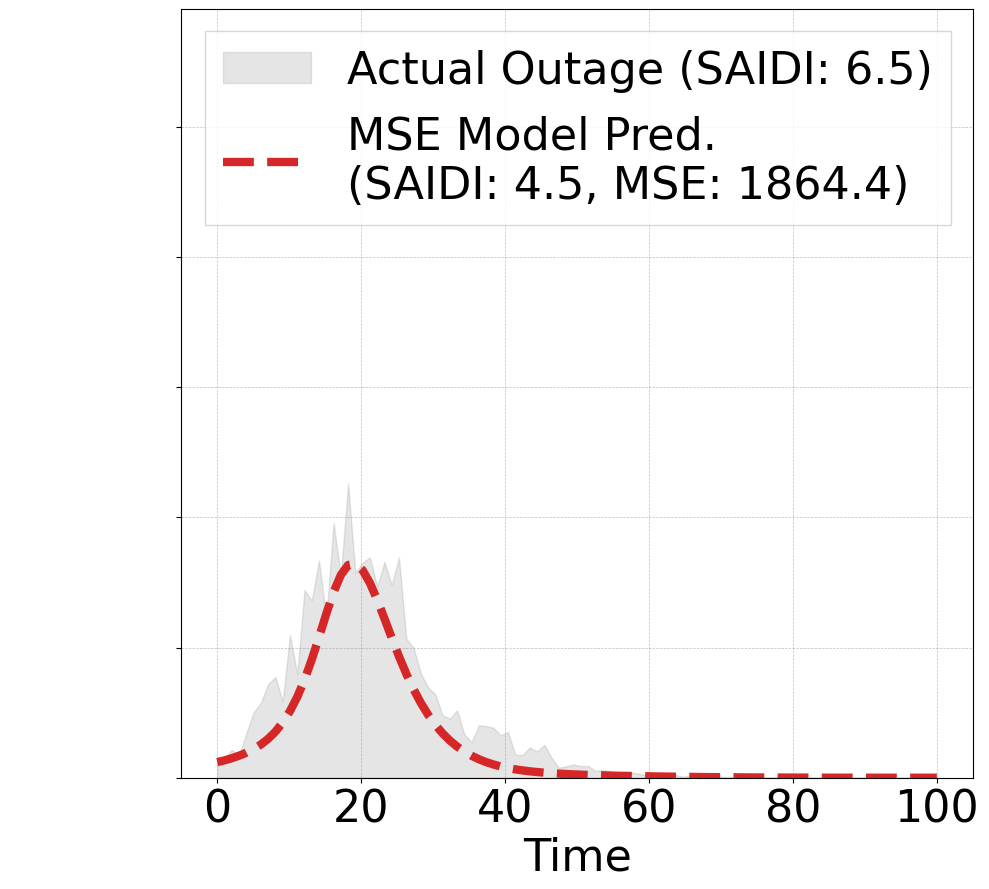

Plot saved to city_3_DFL.pdf


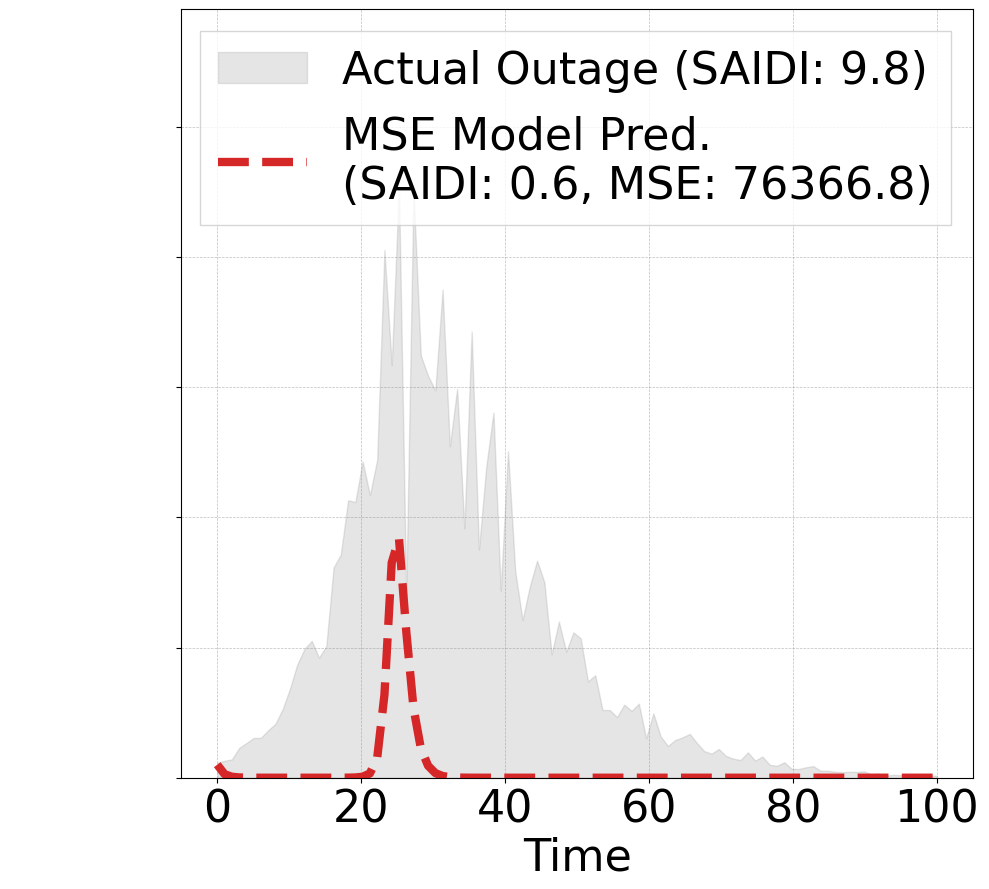

DFL Training - Epoch [8/10], Decision Loss: 36399.3047, MSE Error: 36382.9883
Plot saved to city_1_DFL.pdf


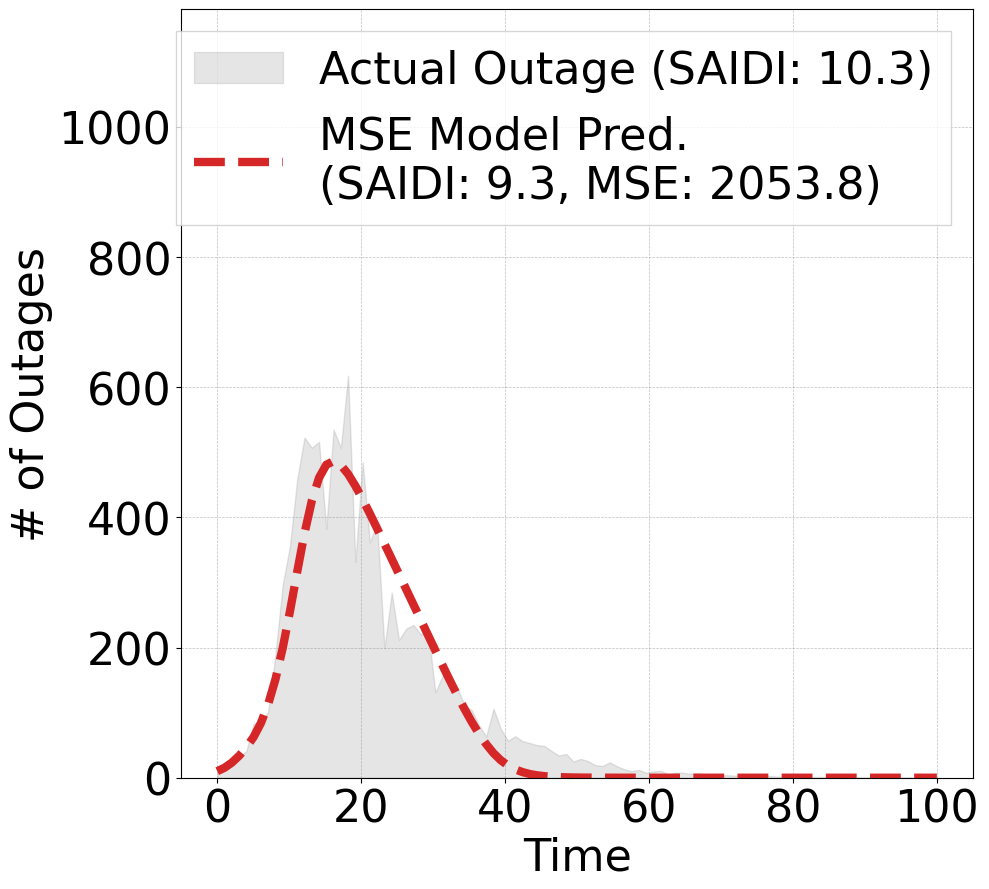

Plot saved to city_2_DFL.pdf


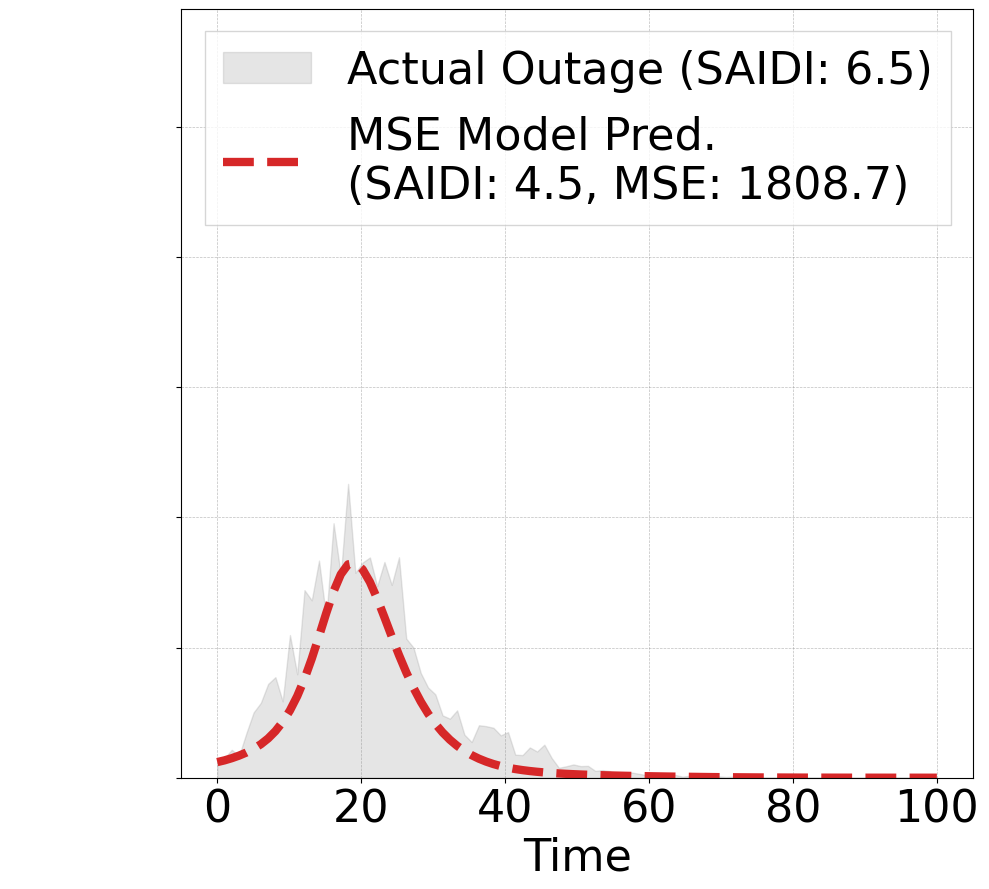

Plot saved to city_3_DFL.pdf


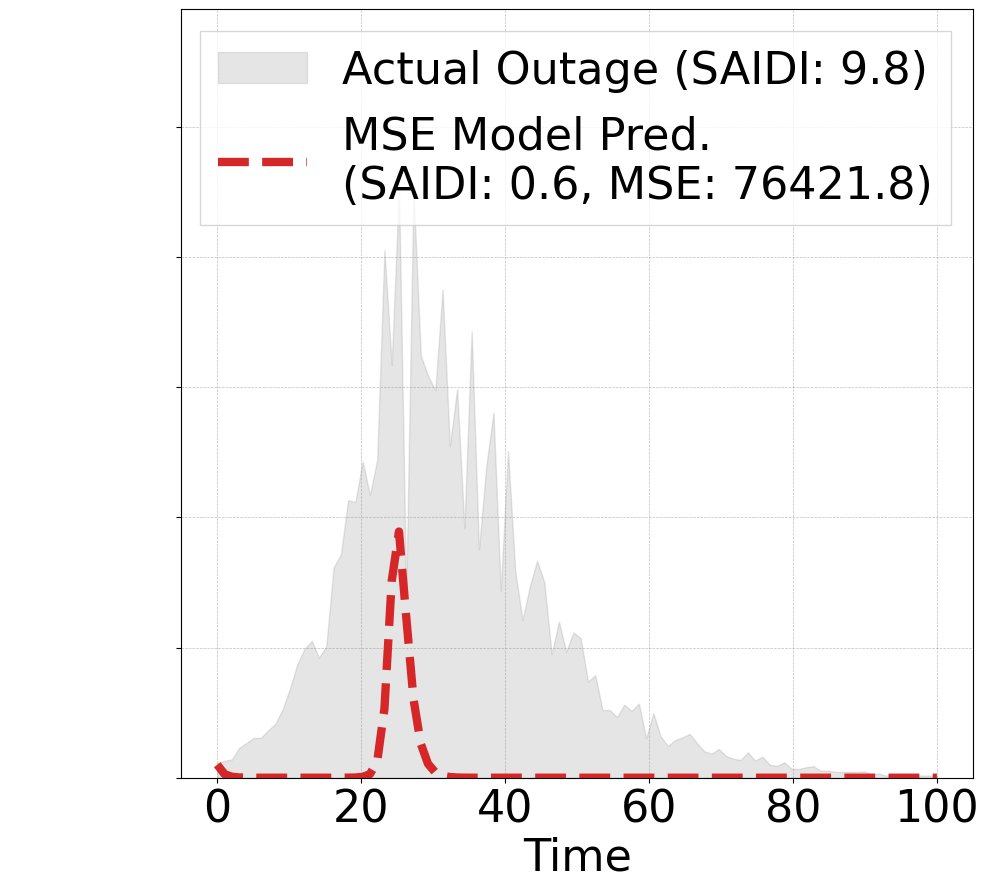

DFL Training - Epoch [9/10], Decision Loss: 36385.3711, MSE Error: 36369.0547
Plot saved to city_1_DFL.pdf


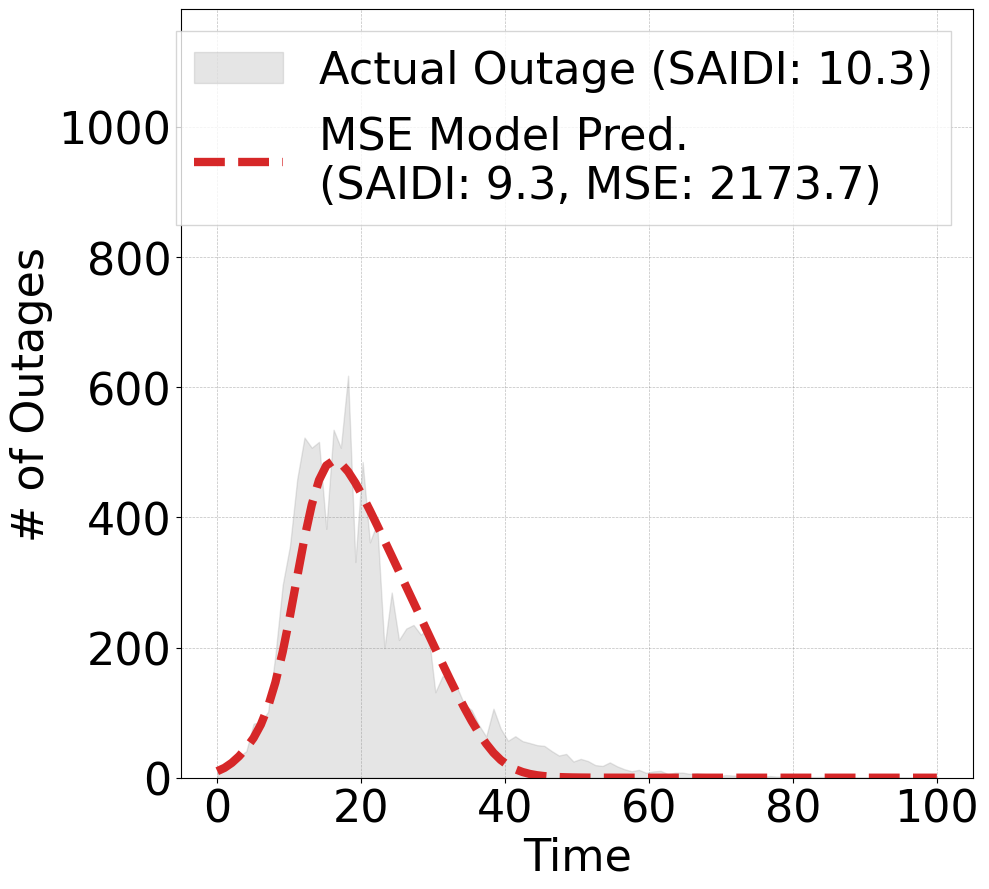

Plot saved to city_2_DFL.pdf


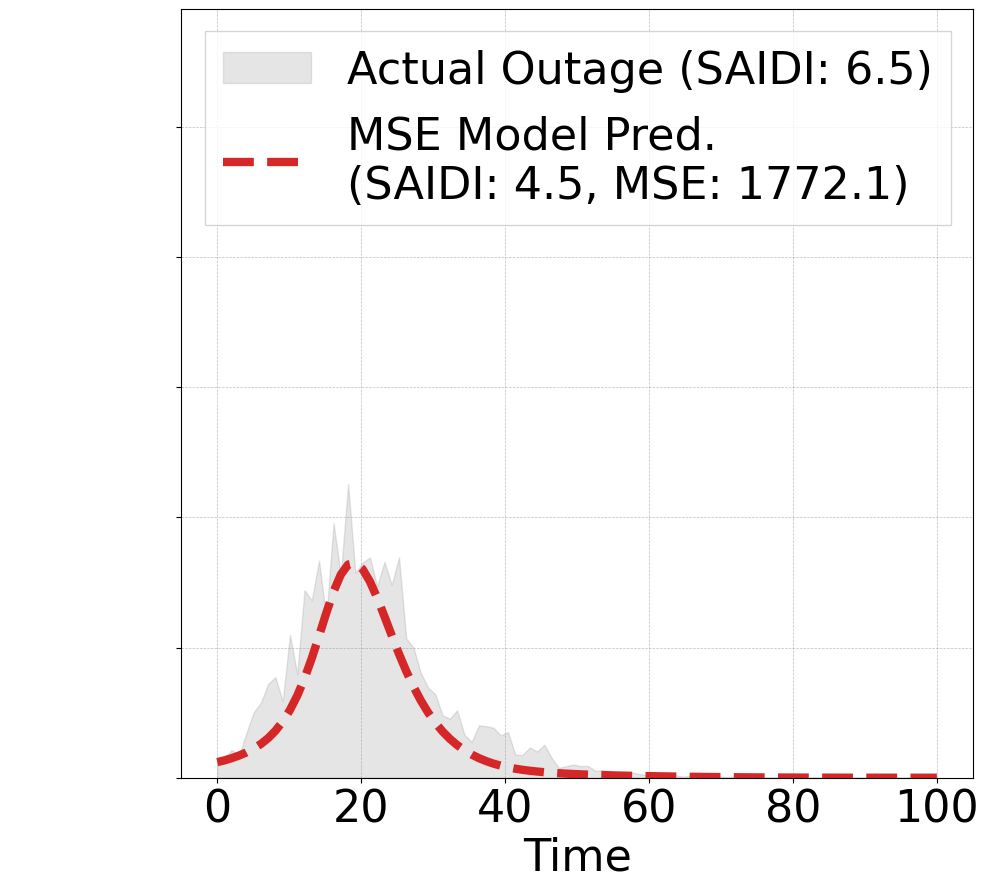

Plot saved to city_3_DFL.pdf


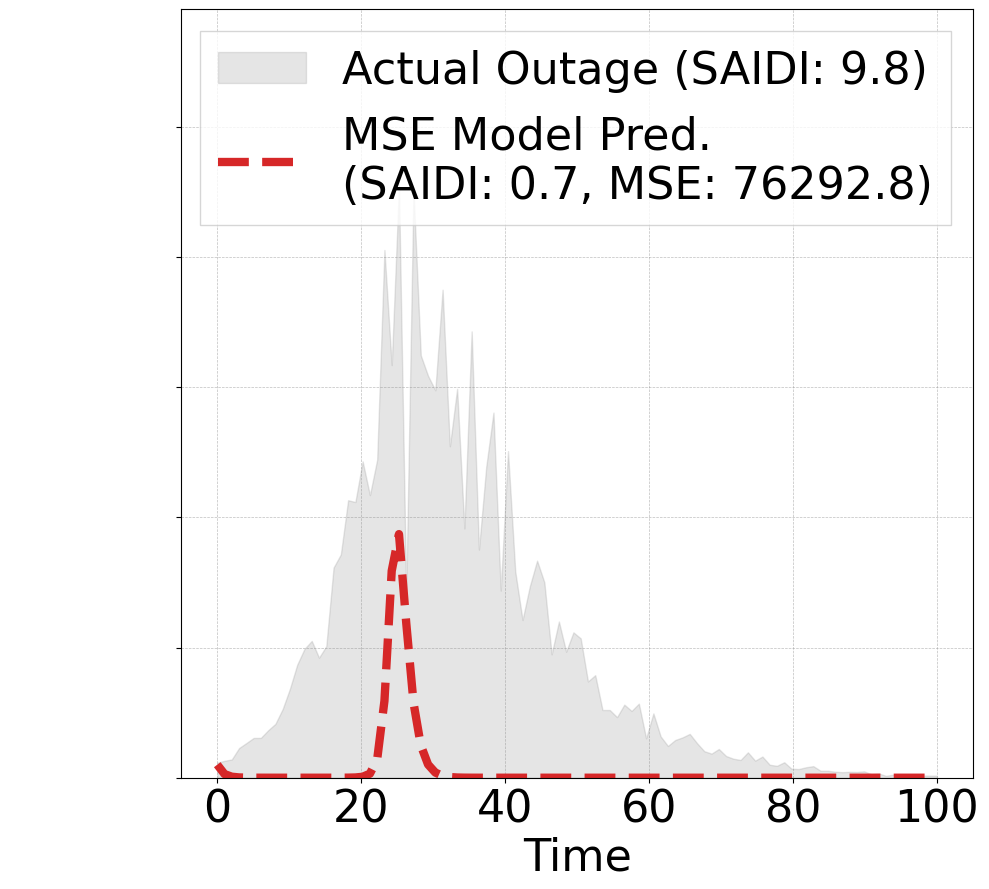

DFL Training - Epoch [10/10], Decision Loss: 36309.9414, MSE Error: 36293.6250
Plot saved to city_1_DFL.pdf


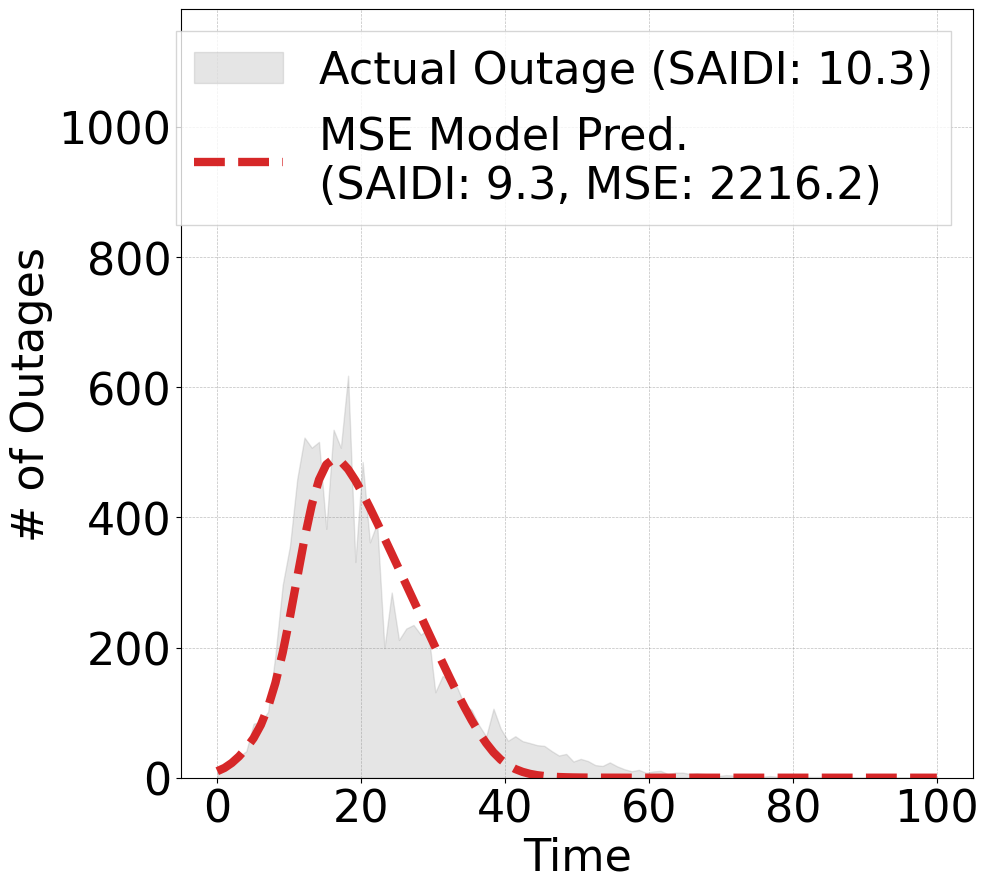

Plot saved to city_2_DFL.pdf


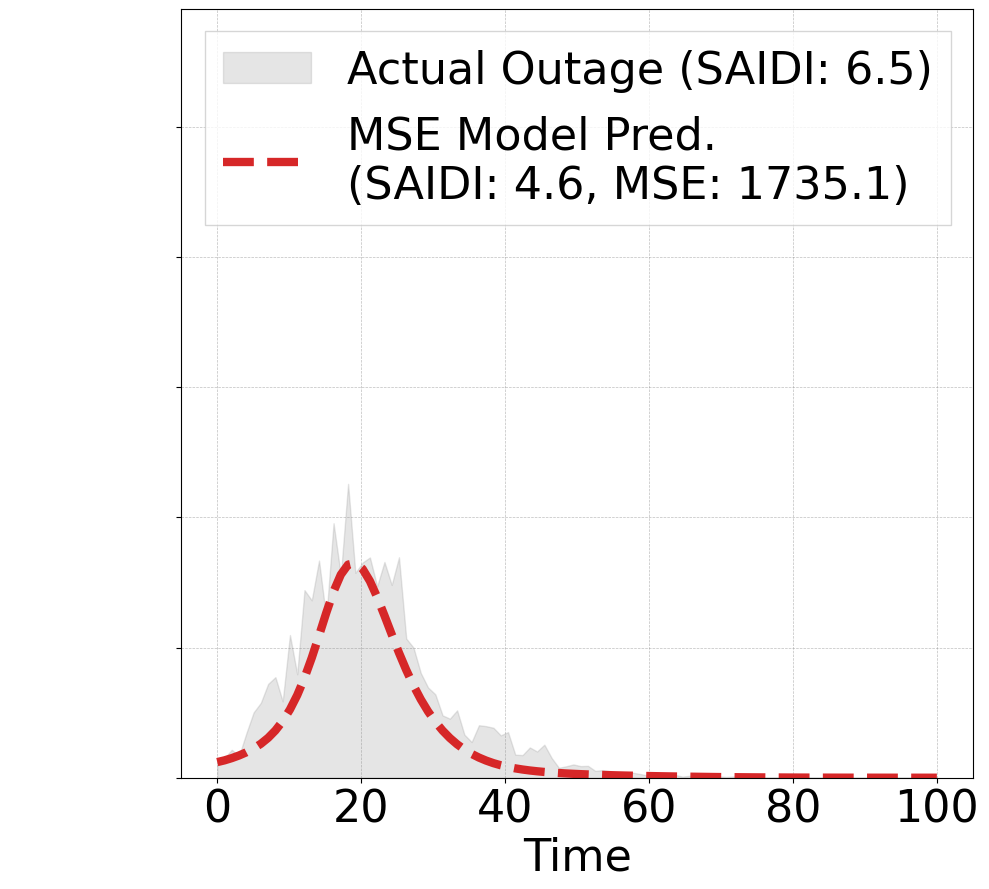

Plot saved to city_3_DFL.pdf


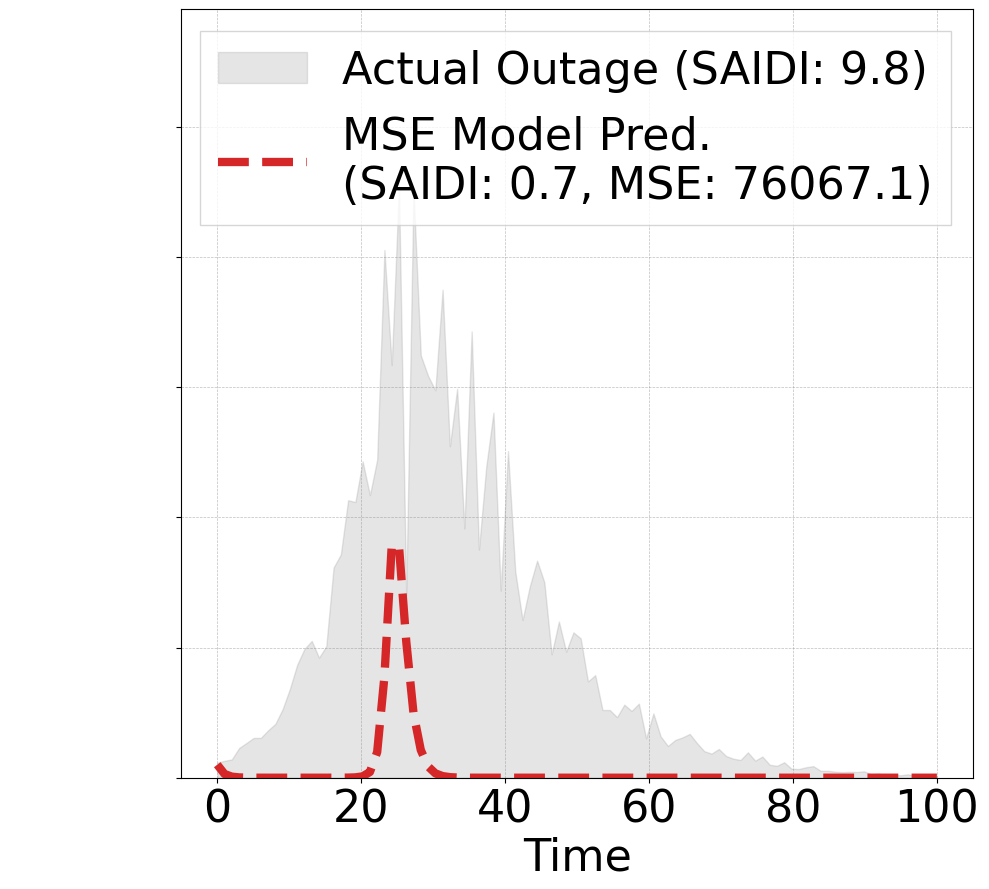

In [ ]:
# Create the CVXPY layer
max_investments = 1
cvxpylayer = create_cvxpy_layer(num_cities, max_investments)


# DFL Training Loop
num_epochs_dfl = 10
optimizer_dfl = torch.optim.Adam(beta_gamma_nn.parameters(), lr=0.001)
customer_tensor = total_households  # Shape: (num_cities,)
decision_losses = []
mse_losses = []

for epoch in range(num_epochs_dfl):
    optimizer_dfl.zero_grad()
    # Forward pass
    pred_outages = odeint(wind_sir_model, initial_conditions, time_points)
    # Compute SAIDI
    I_pred = pred_outages[:, :, 1]  # Shape: (len(time_points), num_cities)
    outage_pred = I_pred.permute(1, 0)  # Shape: (num_cities, len(time_points))
    # pred_outages = odeint(wind_sir_model, initial_conditions, time_points)
    mse_loss = loss_fn(pred_outages, synthetic_outages_noisy)
    SAIDI_pred = calc_SAIDI_torch(customer_tensor, outage_pred)  # Shape: (num_cities,)
    # Use cvxpylayer to get optimal decisions
    x_opt, = cvxpylayer(SAIDI_pred)
    # Compute decision-focused loss

    # Compute SAIDI under true outage data with MSE model's decisions
    with torch.no_grad():
        I_true = synthetic_outages_noisy[:, :, 1]  # Shape: (len(time_points), num_cities)
        outage_true = I_true.permute(1, 0)  # Shape: (num_cities, len(time_points))
        SAIDI_true = calc_SAIDI_torch(customer_tensor, outage_true)
        SAIDI_true_np = SAIDI_true.numpy()

    total_SAIDI = np.sum(SAIDI_true_np)

    decision_loss = total_SAIDI-(torch.matmul(SAIDI_true, x_opt)) + gma * mse_loss
    # Backward pass
    decision_loss.backward()
    optimizer_dfl.step()
    decision_losses.append((total_SAIDI-(torch.matmul(SAIDI_true, x_opt))).item())
    mse_losses.append(mse_loss.item())

    if (epoch + 1) % 1 == 0:
        print(f"DFL Training - Epoch [{epoch + 1}/{num_epochs_dfl}], Decision Loss: {decision_loss.item():.4f}, MSE Error: {mse_loss.item():.4f}")
        # Plot predictions vs true data after MSE training using the function
        pred_outages = odeint(wind_sir_model, initial_conditions, time_points)
        plot_predictions(time_points, synthetic_outages_noisy, pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix = "DFL")


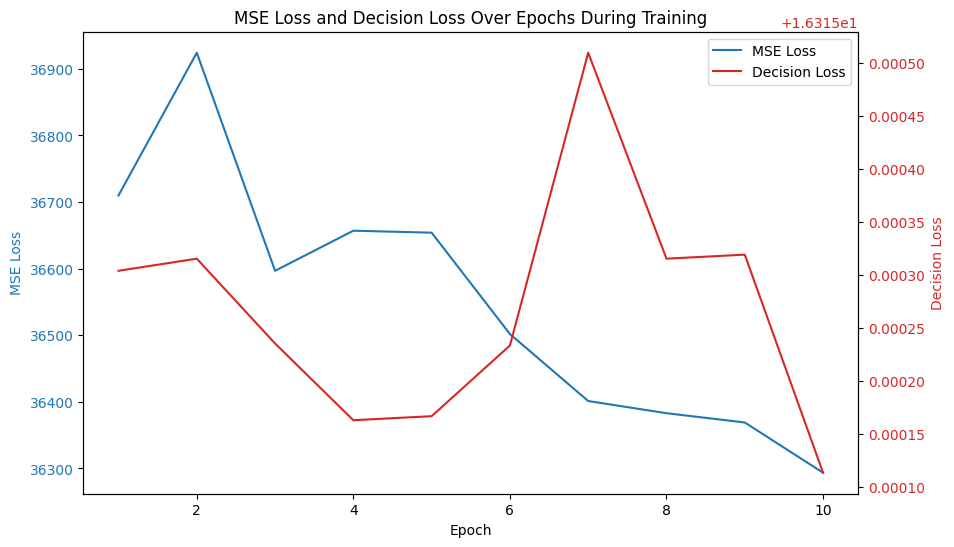

In [ ]:
# Plot decision loss over epochs
# Plot both MSE losses and decision losses on the same plot with different y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss', color=color)
ax1.plot(range(1, 10 + 1), mse_losses, color=color, label='MSE Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Decision Loss', color=color)  # We already handled the x-label with ax1
ax2.plot(range(1, num_epochs_dfl + 1), decision_losses, color=color, label='Decision Loss')
ax2.tick_params(axis='y', labelcolor=color)

# Add a title and adjust layout
plt.title('MSE Loss and Decision Loss Over Epochs During Training')

# Add legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.show()

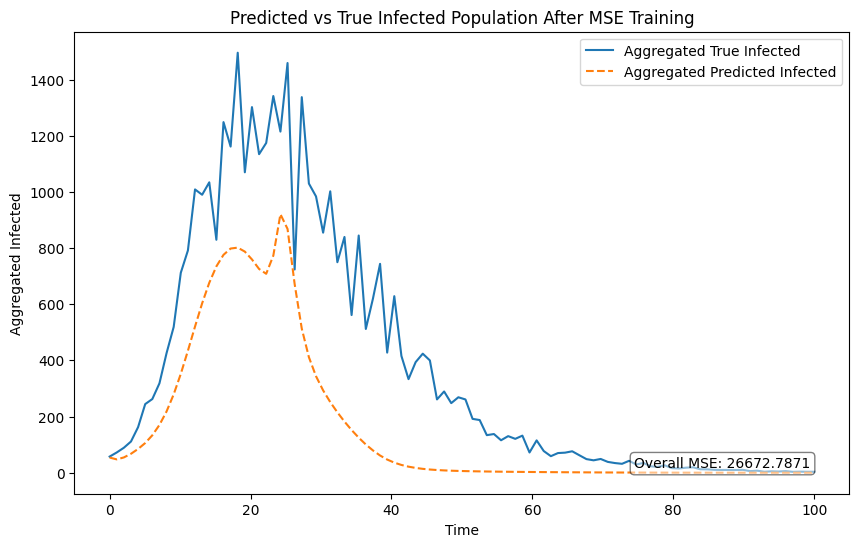

In [ ]:
plot_aggregated_predictions(time_points, synthetic_outages_noisy, pred_outages, num_cities = num_cities, title="Predicted vs True Infected Population After MSE Training")

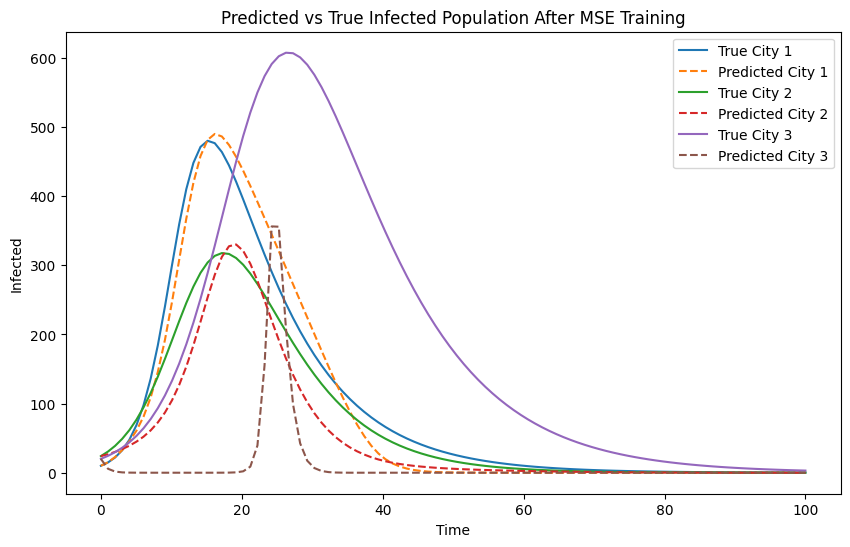

In [ ]:
# Save the model parameters after MSE training
dfl_model_state_dict = beta_gamma_nn.state_dict()

pred_outages = odeint(wind_sir_model, initial_conditions, time_points)

# Plot predictions vs true data after MSE training
plt.figure(figsize=(10, 6))
for city in range(num_cities):
    plt.plot(time_points.numpy(), synthetic_outages[:, city, 1].numpy(), label=f"True City {city+1}")
    plt.plot(time_points.numpy(), pred_outages[:, city, 1].detach().numpy(), linestyle='--', label=f"Predicted City {city+1}")
plt.xlabel("Time")
plt.ylabel("Infected")
plt.legend()
plt.title("Predicted vs True Infected Population After MSE Training")
plt.show()

In [ ]:
def plot_predictions_diff(time_points, synthetic_outages, pred_outages, customer_tensor, city_indices, save_flag=True, filename_suffix="", align_y=True):
    """
    Plots the true and predicted outages for each city, highlighting areas where predictions overestimate or underestimate the actual outages.
    Saves each plot as a PDF file.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        pred_outages (torch.tensor): Predicted outage data. Shape: (len(time_points), num_cities, 3)
        customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
        city_indices (list): List of city indices to plot.
        save_flag (bool): Whether to save the plots. Defaults to True.
        filename_suffix (str): Suffix to append to the filename. Defaults to "".
        align_y (bool): Whether to align the y-axis across all plots. Defaults to True.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import torch  # Ensure torch is imported

    # Determine the global maximum outage value across all cities if alignment is desired
    if align_y:
        outage_true_all = synthetic_outages[:, city_indices, 1]
        outage_pred_all = pred_outages[:, city_indices, 1]
        max_outage_true = torch.max(outage_true_all).item()
        max_outage_pred = torch.max(outage_pred_all).item()
        global_max = max(max_outage_true, max_outage_pred)
        y_max = global_max * 1.3  # Adding 10% padding for better visualization

    for city in city_indices:
        # Extract data for the city
        time = time_points.numpy()
        outage_true = synthetic_outages[:, city, 1].numpy()
        outage_pred = pred_outages[:, city, 1].detach().numpy()
        customer = customer_tensor[city].item()

        # Calculate SAIDI and MSE
        saidi_true = np.sum(outage_true) / customer
        saidi_pred = np.sum(outage_pred) / customer
        mse_value = np.mean((outage_pred - outage_true) ** 2)

        # Determine y-axis maximum for the current plot
        if not align_y:
            current_max = max(np.max(outage_true), np.max(outage_pred))
            y_max_current = current_max * 1.1  # Adding 10% padding
        else:
            y_max_current = y_max

        # Create the plot
        plt.figure(figsize=(10, 9))  # Increased width for better clarity

        # Plot the actual outage with thicker line
        plt.plot(
            time,
            outage_true,
            # label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
            linewidth=6,  # Increased by 2 from 6
            color='tab:blue'
        )


        plt.plot(
        time,
        outage_pred,
        label=f"Predicted Outage\n(SAIDI: {saidi_pred:.1f}, MSE: {mse_value:.1f})",
        linewidth=6,  # Increased by 2 from 4
        linestyle='--',
        color='tab:red'
        )

        # Determine if prediction overestimates or underestimates
        if saidi_pred > saidi_true + 1:
            # Plot the predicted outage with thicker dashed line
            plt.fill_between(
                time,
                outage_true,
                color='lightblue',
                alpha=0.3,
                label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
            )
            # Overestimation: Fill where prediction > actual with salmon
            plt.fill_between(
                time,
                outage_true,
                outage_pred,
                where=(outage_pred > outage_true),
                color='salmon',  # Light red color for overestimation
                alpha=0.4,
                label='Prediction > Actual'
            )

        elif saidi_pred < saidi_true - 1:
            # Underestimation: Fill where prediction < actual with lightblue
            plt.fill_between(
                time,
                [min(i,j) for i,j in zip(outage_true, outage_pred)],
                color='lightblue',
                alpha=0.3,
                label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
            )
            # plt.plot(
            #     time,
            #     outage_true,
            #     label=f"Predicted Outage\n(SAIDI: {saidi_pred:.1f}, MSE: {mse_value:.1f})",
            #     linewidth=6,  # Increased by 2 from 4
            #     linestyle='--',
            #     color='tab:red'
            # )
            plt.fill_between(
                time,
                outage_true,
                outage_pred,
                where=(outage_pred < outage_true),
                color='salmon',  # Light blue color for underestimation
                alpha=0.4,
                label='Prediction < Actual'
            )

        plt.xlabel("Time", fontsize=25)
        plt.ylabel("No. Outage Households", fontsize=18)

        # Set y-axis limit
        plt.ylim(0, y_max_current)

        # Set legend location to upper right
        plt.legend(fontsize=30, loc='upper right')

        # Adjust font sizes for ticks
        plt.xticks(fontsize=25)
        plt.yticks(fontsize=25)

        # Add lighter grid lines
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='grey', alpha=0.5)

        # Tight layout to minimize white space
        plt.tight_layout()

        if save_flag:
            # Save the plot to a PDF file with the custom suffix
            filename = f"city_{city+1}_{filename_suffix}.pdf"
            plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
            print(f"Plot saved to {filename}")

        # Show the plot
        plt.show()

        # Close the figure to free memory
        plt.close()

Plot saved to city_1_DFL.pdf


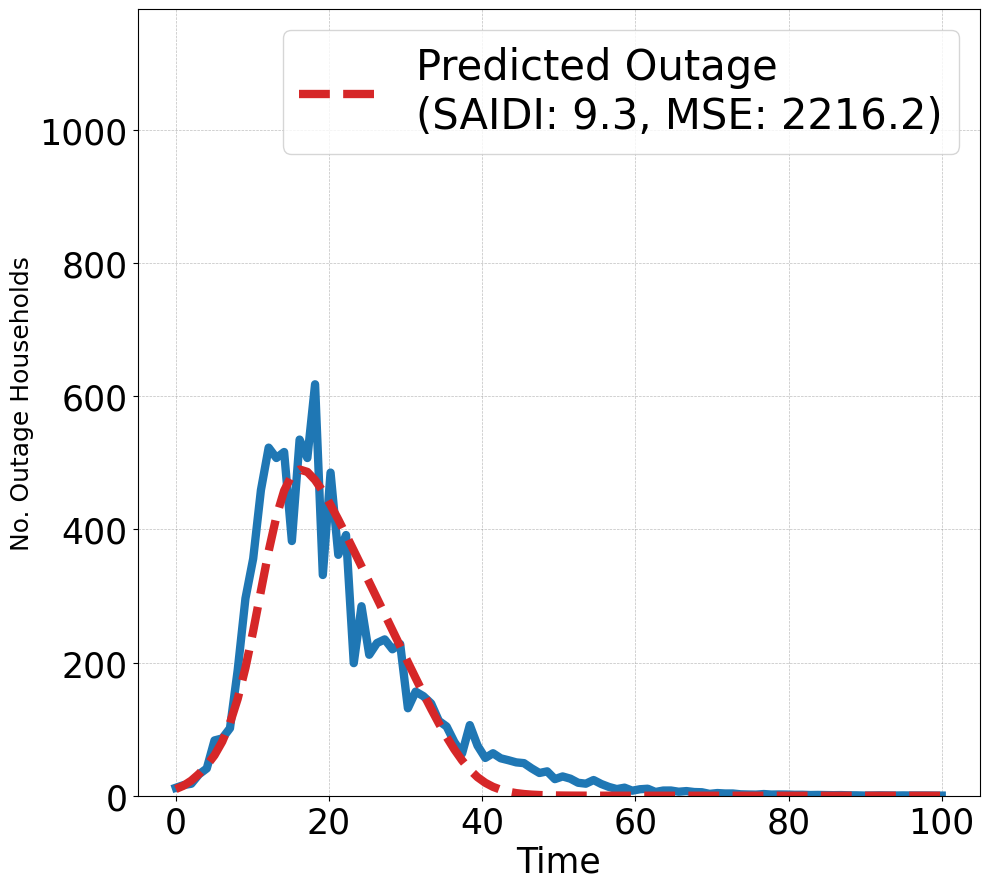

Plot saved to city_2_DFL.pdf


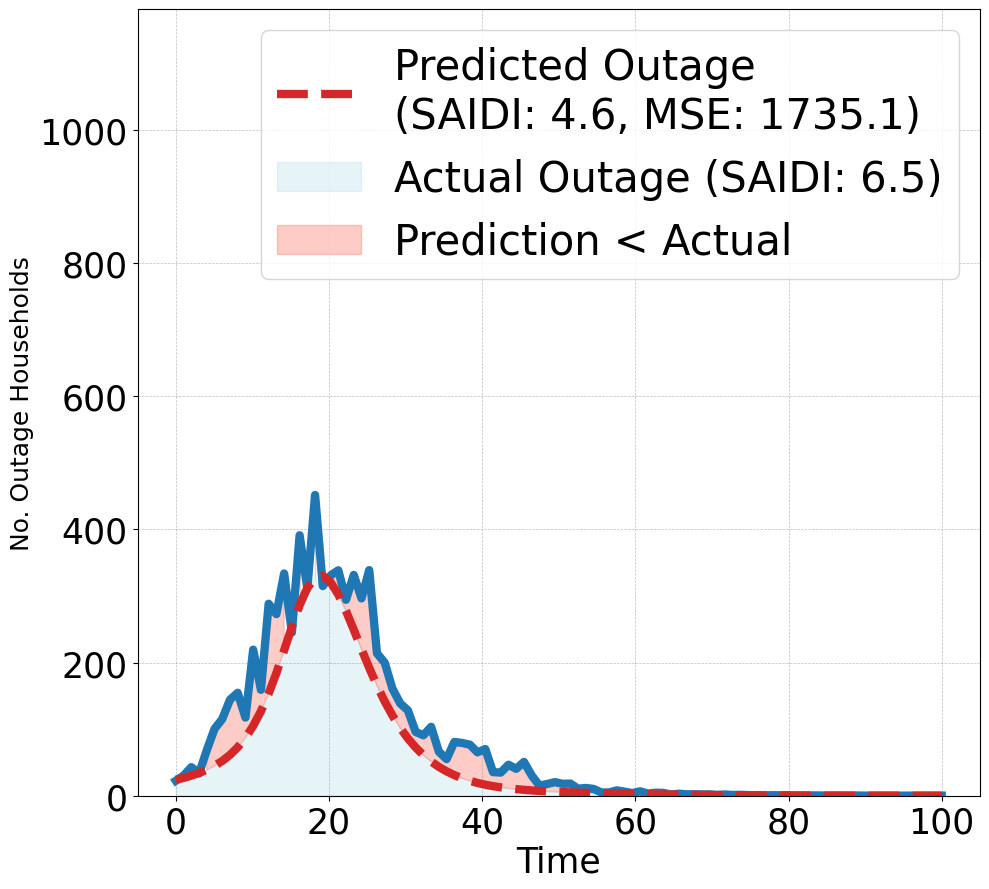

Plot saved to city_3_DFL.pdf


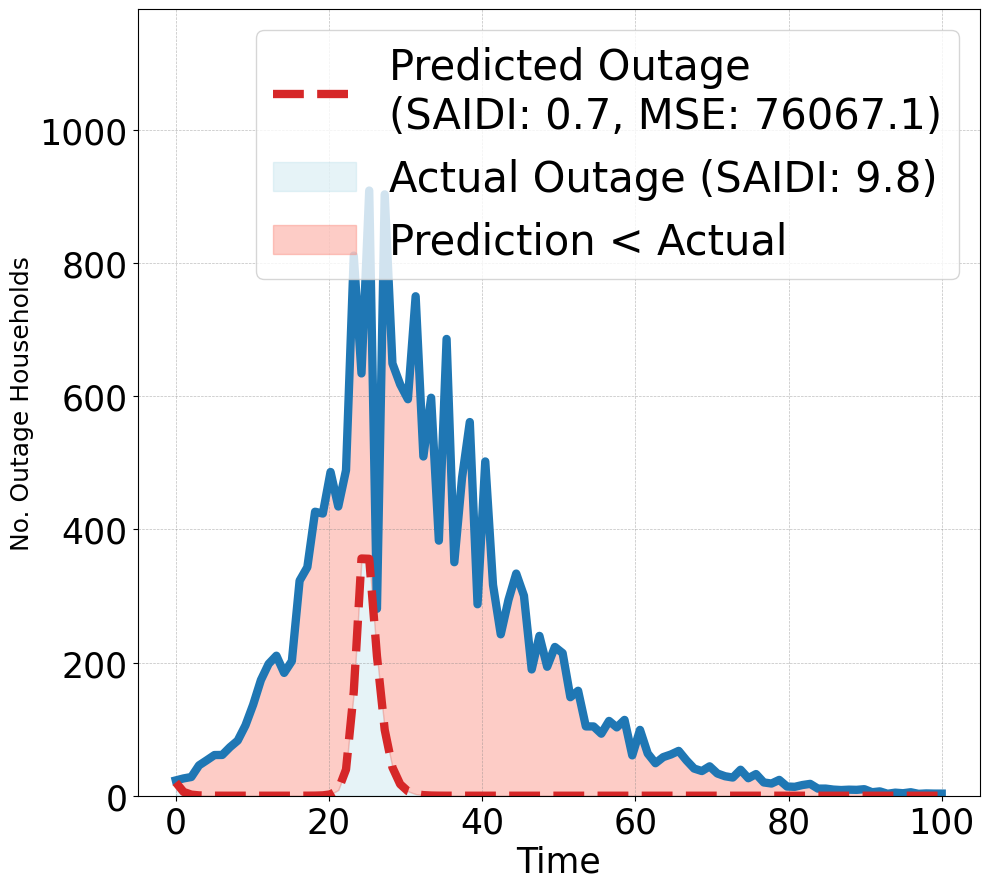

In [ ]:
# Plot predictions vs true data after MSE training using the function
plot_predictions_diff(time_points, synthetic_outages_noisy, pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix="DFL")

In [ ]:
def plot_predictions_diff_v2(
    time_points, synthetic_outages, dfl_pred_outages, mse_pred_outages, customer_tensor, city_indices, save_flag=True, filename_suffix="", align_y=True
):
    """
    Plots the true and predicted outages for each city, highlighting areas where predictions overestimate or underestimate the actual outages.
    Saves each plot as a PDF file.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        dfl_pred_outages (torch.tensor): DFL-predicted outage data. Shape: (len(time_points), num_cities, 3)
        mse_pred_outages (torch.tensor): MSE-predicted outage data. Shape: (len(time_points), num_cities, 3)
        customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
        city_indices (list): List of city indices to plot.
        save_flag (bool): Whether to save the plots. Defaults to True.
        filename_suffix (str): Suffix to append to the filename. Defaults to "".
        align_y (bool): Whether to align the y-axis across all plots. Defaults to True.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    # Determine the global maximum outage value across all cities if alignment is desired
    if align_y:
        outage_true_all = synthetic_outages[:, city_indices, 1]
        max_outage_true = torch.max(outage_true_all).item()
        y_max = max_outage_true * 1.3  # Adding 30% padding for better visualization

    for city in city_indices:
        # Extract data for the city
        time = time_points.numpy()
        outage_true = synthetic_outages[:, city, 1].numpy()
        dfl_pred = dfl_pred_outages[:, city, 1].detach().numpy()
        mse_pred = mse_pred_outages[:, city, 1].detach().numpy()
        customer = customer_tensor[city].item()

        # Calculate SAIDI and MSE
        saidi_true = np.sum(outage_true) / customer
        saidi_dfl = np.sum(dfl_pred) / customer
        saidi_mse = np.sum(mse_pred) / customer
        mse_value_dfl = np.mean((dfl_pred - outage_true) ** 2)
        mse_value_mse = np.mean((mse_pred - outage_true) ** 2)

        # Determine y-axis maximum for the current plot
        if not align_y:
            current_max = max(np.max(outage_true), np.max(dfl_pred), np.max(mse_pred))
            y_max_current = current_max * 1.1  # Adding 10% padding
        else:
            y_max_current = y_max

        # Create the plot
        # plt.figure(figsize=(12, 9))
        plt.figure(figsize=(10, 9))  # Increased width for better clarity


        # Plot the actual outage
        # plt.plot(
        #     time,
        #     outage_true,
        #     label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
        #     linewidth=6,
        #     color="tab:blue",
        # )

        # Highlight the area under the true outage curve with grey
        plt.fill_between(
            time,
            0,
            outage_true,
            color="grey",
            alpha=0.2,
            label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
        )

        # Plot the DFL prediction
        plt.plot(
            time,
            dfl_pred,
            # label=f"MSE Model Pred.\n(SAIDI: {saidi_dfl:.1f}, MSE: {mse_value_dfl:.1f})",
            linewidth=6,
            linestyle="--",
            color="tab:green",
        )

        # Plot the MSE prediction
        plt.plot(
            time,
            mse_pred,
            label=f"DFL Model Pred.\n(SAIDI: {saidi_mse:.1f}, MSE: {mse_value_mse:.1f})",
            linewidth=6,
            linestyle="--",
            color="tab:red",
        )

        # Highlight areas where DFL > MSE (green) and DFL <= MSE (salmon)
        plt.fill_between(
            time,
            dfl_pred,
            mse_pred,
            where=(dfl_pred > mse_pred),
            color="green",
            alpha=0.2,
            interpolate=True,
            # label="DFL Pred. > MSE Pred.",
        )
        plt.fill_between(
            time,
            dfl_pred,
            mse_pred,
            where=(dfl_pred <= mse_pred),
            color="salmon",
            alpha=0.4,
            interpolate=True,
            # label="DFL Pred. <= MSE Pred.",
        )



        # Set plot labels and limits
        plt.xlabel("Time", fontsize=25)
        plt.ylabel("No. of Outage Households", fontsize=25)
        plt.ylim(0, y_max_current)

        # Add legend and grid
        plt.legend(fontsize=30, loc="upper right", fancybox = False)
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, color="grey", alpha=0.5)

        # Adjust font sizes
        plt.xticks(fontsize=25)
        plt.yticks(fontsize=25)

        # Optimize layout
        plt.tight_layout()

        # Save the plot if required
        if save_flag:
            filename = f"city_{city + 1}_{filename_suffix}.pdf"
            plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
            print(f"Plot saved to {filename}")

        # Show the plot
        plt.show()

        # Close the figure to free memory
        plt.close()


In [ ]:
def plot_predictions_diff_v3(
    time_points, synthetic_outages, dfl_pred_outages, mse_pred_outages, customer_tensor, city_indices, save_flag=True, filename_suffix="", align_y=True
):
    """
    Plots the true and predicted outages for each city, highlighting areas where predictions overestimate or underestimate the actual outages.
    Saves each plot as a PDF file.

    Args:
        time_points (torch.tensor): Time points used in simulation.
        synthetic_outages (torch.tensor): True outage data. Shape: (len(time_points), num_cities, 3)
        dfl_pred_outages (torch.tensor): DFL-predicted outage data. Shape: (len(time_points), num_cities, 3)
        mse_pred_outages (torch.tensor): MSE-predicted outage data. Shape: (len(time_points), num_cities, 3)
        customer_tensor (torch.tensor): Total customers for each city. Shape: (num_cities,)
        city_indices (list): List of city indices to plot.
        save_flag (bool): Whether to save the plots. Defaults to True.
        filename_suffix (str): Suffix to append to the filename. Defaults to "".
        align_y (bool): Whether to align the y-axis across all plots. Defaults to True.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    # Determine the global maximum outage value across all cities if alignment is desired
    if align_y:
        outage_true_all = synthetic_outages[:, city_indices, 1]
        max_outage_true = torch.max(outage_true_all).item()
        y_max = max_outage_true * 1.3  # Adding 30% padding for better visualization

    for idx, city in enumerate(city_indices):
        # Extract data for the city
        time = time_points.numpy()
        outage_true = synthetic_outages[:, city, 1].numpy()
        dfl_pred = dfl_pred_outages[:, city, 1].detach().numpy()
        mse_pred = mse_pred_outages[:, city, 1].detach().numpy()
        customer = customer_tensor[city].item()

        # Calculate SAIDI and MSE
        saidi_true = np.sum(outage_true) / customer
        saidi_dfl = np.sum(dfl_pred) / customer
        saidi_mse = np.sum(mse_pred) / customer
        mse_value_dfl = np.mean((dfl_pred - outage_true) ** 2)
        mse_value_mse = np.mean((mse_pred - outage_true) ** 2)

        # Determine y-axis maximum for the current plot
        if not align_y:
            current_max = max(np.max(outage_true), np.max(dfl_pred), np.max(mse_pred))
            y_max_current = current_max * 1.1  # Adding 10% padding
        else:
            y_max_current = y_max

        # Create the plot
        # plt.figure(figsize=(12, 9))
        plt.figure(figsize=(10, 12))  # Increased width for better clarity


        # Plot the actual outage
        # plt.plot(
        #     time,
        #     outage_true,
        #     label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
        #     linewidth=6,
        #     color="tab:blue",
        # )

        # Highlight the area under the true outage curve with grey
        plt.fill_between(
            time,
            0,
            outage_true,
            color="grey",
            alpha=0.2,
            label=f"Actual Outage (SAIDI: {saidi_true:.1f})",
        )

        # Plot the DFL prediction
        plt.plot(
            time,
            dfl_pred,
            label=f"DFL Model Pred.\n(SAIDI: {saidi_dfl:.1f}, MSE: {mse_value_dfl:.1f})",
            linewidth=9,
            linestyle="--",
            color="tab:green",
        )

        # Plot the MSE prediction
        plt.plot(
            time,
            mse_pred,
            label=f"MSE Model Pred.\n(SAIDI: {saidi_mse:.1f}, MSE: {mse_value_mse:.1f})",
            linewidth=6,
            linestyle="--",
            color="tab:red",
        )

        # Highlight areas where DFL > MSE (green) and DFL <= MSE (salmon)
        plt.fill_between(
            time,
            dfl_pred,
            mse_pred,
            where=(dfl_pred > mse_pred),
            color="green",
            alpha=0.2,
            interpolate=True,
            # label="DFL Pred. > MSE Pred.",
        )
        plt.fill_between(
            time,
            dfl_pred,
            mse_pred,
            where=(dfl_pred <= mse_pred),
            color="salmon",
            alpha=0.2,
            interpolate=True,
            # label="DFL Pred. <= MSE Pred.",
        )


        # Set plot labels and limits
        plt.xlabel("Time", fontsize=32)
        # plt.ylabel("No. of Outage Households", fontsize=32)
        if idx == 0:
            plt.ylabel("# of Outages", fontsize=32)
            # Customize the y-ticks to show every 200 units
            y_ticks = np.arange(0, y_max_current + 1, 200)
            plt.yticks(y_ticks, fontsize=32)
        else:
            # Make y-axis label and ticks transparent for city 2 and 3
            plt.ylabel("# of Outages", fontsize=2, color="white", alpha=0)  # Transparent label
            y_ticks = np.arange(0, y_max_current + 1, 200)
            plt.yticks(y_ticks, fontsize=2, color="white", alpha=0)  # Transparent ticks

        plt.ylim(0, y_max_current)

        # Add legend and grid
        plt.legend(fontsize=32, loc="upper right", fancybox = False)
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, color="grey", alpha=0.5)
        # Customize plot spines (thicker box)
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(3)  # Set thicker line width

        # Adjust font sizes
        plt.xticks(fontsize=32)
        plt.yticks(fontsize=32)

        # Optimize layout
        plt.tight_layout()

        # Save the plot if required
        if save_flag:
            filename = f"city_{city + 1}_{filename_suffix}.pdf"
            plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
            print(f"Plot saved to {filename}")

        # Show the plot
        plt.show()

        # Close the figure to free memory
        plt.close()


<ipython-input-343-66128eccbde1>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mse_wind_sir_model.load_state_dict(torch.load(model_save_path))


Model loaded from wind_sir_model.pth
Plot saved to city_1_DFL.pdf


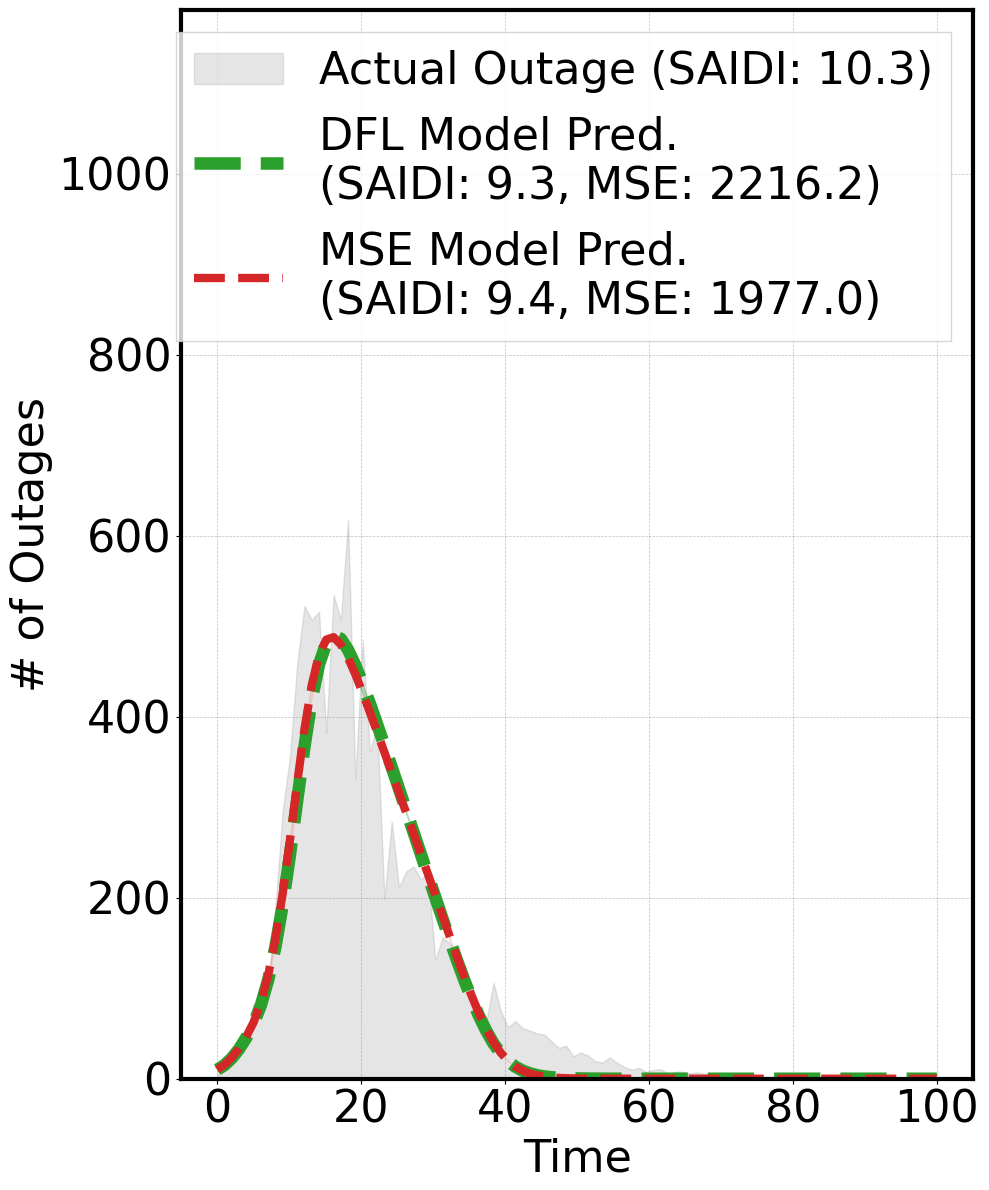

Plot saved to city_2_DFL.pdf


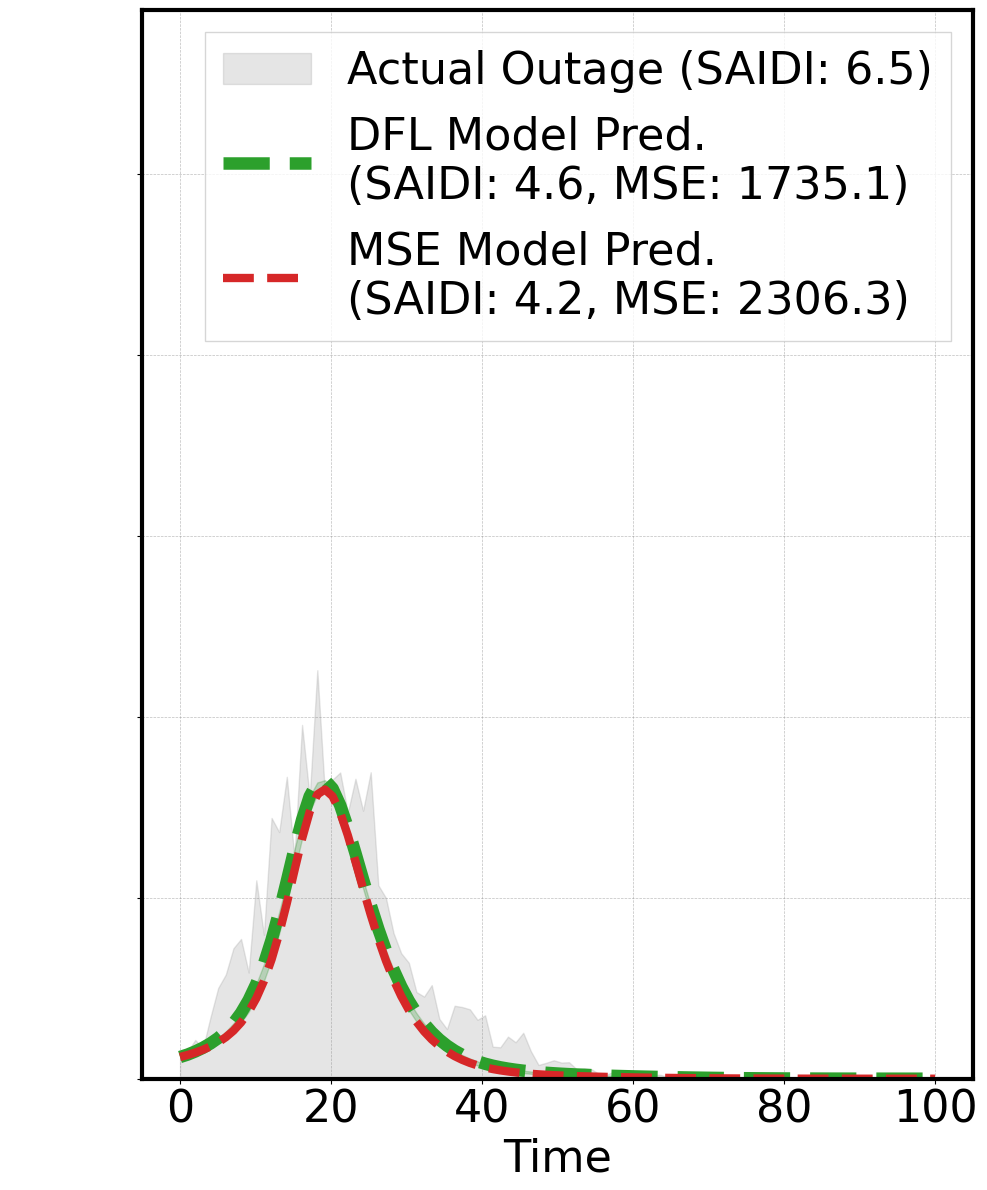

Plot saved to city_3_DFL.pdf


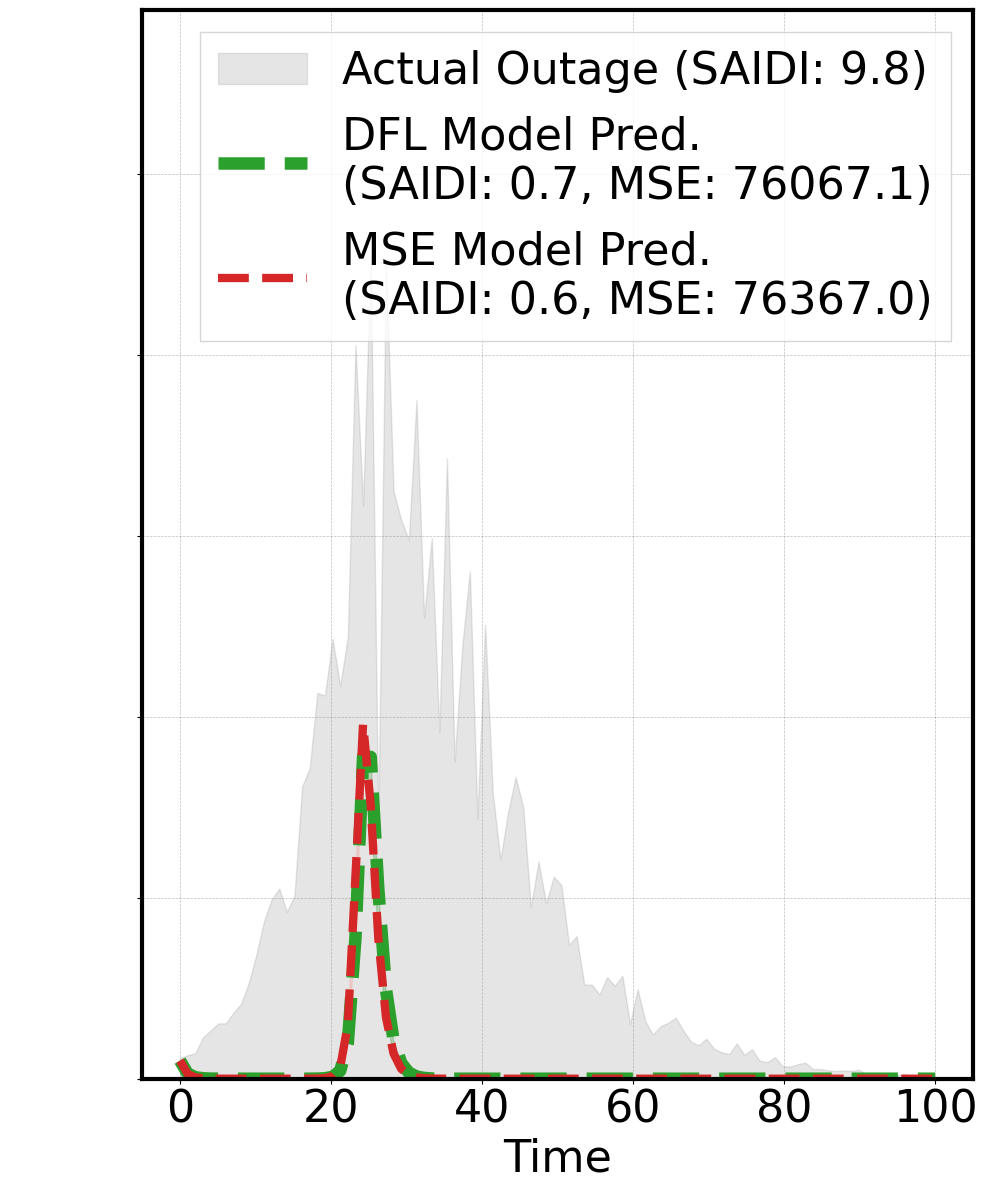

In [ ]:
# To load the model parameters later
# Create a new instance of the model (make sure the model architecture is the same)
# beta_gamma_nn_loaded = BetaGammaNN(input_size, hidden_size, num_cities)
# wind_sir_model_loaded = WindSIRModel(beta_gamma_nn_loaded, wind_speeds, time_points)
beta_gamma_nn = BetaGammaNN(input_size, hidden_size, num_cities)

# Initialize the WindSIRModel
mse_wind_sir_model = WindSIRModel(beta_gamma_nn, wind_speeds, time_points)
# Load the saved state dictionary into the model
mse_wind_sir_model.load_state_dict(torch.load(model_save_path))
print("Model loaded from", model_save_path)

dfl_pred_outages = odeint(wind_sir_model, initial_conditions, time_points)
mse_pred_outages = odeint(mse_wind_sir_model, initial_conditions, time_points)

# Plot predictions vs true data after MSE training using the function
plot_predictions_diff_v3(time_points, synthetic_outages_noisy, dfl_pred_outages,mse_pred_outages, customer_tensor, city_indices=range(num_cities), filename_suffix="DFL")

In [ ]:
# Step 4: Evaluate the decision loss using Gurobi before and after DFL training and under the true outage data
# Function to solve optimization problem using Gurobi
def solve_optimization_gurobi(SAIDI_values, max_investments):
    num_cities = len(SAIDI_values)
    gurobi_model = gp.Model()
    x = gurobi_model.addVars(num_cities, vtype=GRB.BINARY, name="x")
    gurobi_model.setObjective(gp.quicksum(SAIDI_values[i] * x[i] for i in range(num_cities)), GRB.MAXIMIZE)
    gurobi_model.addConstr(gp.quicksum(x[i] for i in range(num_cities)) <= max_investments)
    gurobi_model.Params.OutputFlag = 0  # Suppress output
    gurobi_model.optimize()
    x_values = np.array([x[i].X for i in range(num_cities)])
    return x_values

# Evaluate after DFL training
with torch.no_grad():
    pred_outages_dfl = odeint(wind_sir_model, initial_conditions, time_points)
    I_pred_dfl = pred_outages_dfl[:, :, 1]
    outage_pred_dfl = I_pred_dfl.permute(1, 0)
    SAIDI_pred_dfl = calc_SAIDI_torch(customer_tensor, outage_pred_dfl)
    SAIDI_pred_dfl_np = SAIDI_pred_dfl.numpy()

# Solve optimization problem using Gurobi with DFL model's predictions
x_opt_dfl = solve_optimization_gurobi(SAIDI_pred_dfl_np, max_investments)

# Compute SAIDI under true outage data with DFL model's decisions
total_SAIDI_dfl = np.sum(SAIDI_true_np) - np.dot(SAIDI_true_np, x_opt_dfl)
print(f"Total SAIDI under true data with DFL model's decisions: {total_SAIDI_dfl:.4f}")


# Evaluate before DFL training (after MSE training)
# Load MSE model parameters
# Load the saved state dictionary into the model
wind_sir_model.load_state_dict(torch.load(model_save_path))
print("Model loaded from", model_save_path)
# beta_gamma_nn.load_state_dict(mse_model_state_dict)

with torch.no_grad():
    pred_outages_mse = odeint(wind_sir_model, initial_conditions, time_points)
    I_pred_mse = pred_outages_mse[:, :, 1]
    outage_pred_mse = I_pred_mse.permute(1, 0)
    SAIDI_pred_mse = calc_SAIDI_torch(customer_tensor, outage_pred_mse)
    SAIDI_pred_mse_np = SAIDI_pred_mse.numpy()

# Solve optimization problem using Gurobi with MSE model's predictions
x_opt_mse = solve_optimization_gurobi(SAIDI_pred_mse_np, max_investments)

# Compute SAIDI under true outage data with MSE model's decisions
with torch.no_grad():
    I_true = synthetic_outages[:, :, 1]  # Shape: (len(time_points), num_cities)
    outage_true = I_true.permute(1, 0)  # Shape: (num_cities, len(time_points))
    SAIDI_true = calc_SAIDI_torch(customer_tensor, outage_true)
    # SAIDI_true_np = SAIDI_true.numpy()

total_SAIDI_mse = np.sum(SAIDI_true_np) - np.dot(SAIDI_true_np, x_opt_mse)
print(f"Total SAIDI under true data with MSE model's decisions: {total_SAIDI_mse:.4f}")

Total SAIDI under true data with DFL model's decisions: 16.3152
Model loaded from wind_sir_model.pth


<ipython-input-344-4727e6003916>:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  wind_sir_model.load_state_dict(torch.load(model_save_path))


Total SAIDI under true data with MSE model's decisions: 16.3152


In [ ]:
x_opt_best = solve_optimization_gurobi(SAIDI_true, max_investments)
total_SAIDI_best = np.sum(SAIDI_true_np) - np.dot(SAIDI_true_np, x_opt_best)

In [ ]:
# Compare decisions and total SAIDI
print("\nComparison of Decisions and Total SAIDI:")
print(f"MSE Model Decisions: {x_opt_mse}")
print(f"DFL Model Decisions: {x_opt_dfl}")
print(f"Best Decisions Based on Groundtruth: {x_opt_best}")
print(f"Total SAIDI under true data with MSE decisions: {total_SAIDI_mse:.4f}")
print(f"Total SAIDI under true data with DFL decisions: {total_SAIDI_dfl:.4f}")
print(f"Total SAIDI under true data with best decisions: {total_SAIDI_best:.4f}")


Comparison of Decisions and Total SAIDI:
MSE Model Decisions: [1. 0. 0.]
DFL Model Decisions: [1. 0. 0.]
Best Decisions Based on Groundtruth: [1. 0. 0.]
Total SAIDI under true data with MSE decisions: 16.3152
Total SAIDI under true data with DFL decisions: 16.3152
Total SAIDI under true data with best decisions: 16.3152


In [ ]:
dfl_pred = dfl_pred_outages[:, city, 1].detach().numpy()
mse_pred = mse_pred_outages[:, city, 1].detach().numpy()

mse_value_dfl = np.mean((dfl_pred - outage_true.numpy()) ** 2)
mse_value_mse = np.mean((mse_pred - outage_true.numpy()) ** 2)
print(f"MSE with DFL: {mse_value_dfl:.4f}")
print(f"MSE with MSE: {mse_value_mse:.4f}")

MSE with DFL: 33828.7617
MSE with MSE: 33925.2852


In [ ]:
import pandas as pd
# Create a dictionary to store all results
results_dict = {
    "seed": seed,
    "mse_epochs": num_epochs,
    "dfl_epochs": num_epochs_dfl,
    "lda": lda,
    "lambda_mse":gma,
    "mse_error_pred": mse_value_mse,
    "mse_error_dfl": mse_value_dfl,
    "total_cost_pred": total_SAIDI_mse,
    "total_cost_dfl": total_SAIDI_dfl,
    "total_cost_gt": total_SAIDI_best
}

# Create a pandas DataFrame with one row containing the results
df = pd.DataFrame([results_dict])

# Define the file path on Google Drive (adjust the path as needed)
csv_file_path = 'underground_experiment_results_1.csv'

# Save the DataFrame to a CSV file (this will replace any existing file)
df.to_csv(csv_file_path, index=False)
print("Results saved to", csv_file_path)

Results saved to underground_experiment_results_1.csv
